In [1]:
%matplotlib inline
import numpy as np
from scipy.spatial.transform import Rotation as R

from numpy import savetxt
from res import RESERVOIRE_SIMPLE

import matplotlib.pyplot as plt
from numpy import linalg as LA
import numpy as np

import torch
import torch.optim as optim
import torch.linalg as LA
import matplotlib.pyplot as plt
from tqdm import trange
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import zscore
from tqdm import tqdm

N_PC_MODEL = 100

input_factor = 0.

if_save_res = False
if_load_res = False

sigma_dynamics = .0

recurrent_factor = .1


In [2]:
import os
import numpy as np
from scipy.signal import butter, filtfilt

def lowpass_filter_rows(X, fs, cutoff, order=4):
    # X: N x T matrix
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    
    return np.array([filtfilt(b, a, row) for row in X])

# Example
fs = 1000        # sampling frequency (Hz)
cutoff = 150      # cutoff frequency (Hz)

# Load motion-corrected timeseries from subfolder structure
timeseries_root = "./timeseries"
folder_to_label = {'CN': 'CC', 'AD': 'AD', 'MCI': 'MCI'}

collected_signals = []
identifiers = []

for subfolder, label in folder_to_label.items():
    folder_path = os.path.join(timeseries_root, subfolder)
    file_list = sorted([f for f in os.listdir(folder_path) if f.endswith('.npy')])
    for fname in file_list:
        arr = np.load(os.path.join(folder_path, fname)).T  # files are (parcels, time); transpose to (time, parcels)
        #arr = (arr - arr.mean(axis=0)) / (arr.std(axis=0) + 1e-8)  # Centering and scaling
        #arr = lowpass_filter_rows(arr.T, fs, cutoff).T
        collected_signals.append(arr)
        patient_id = fname.split('_ses-')[0]
        identifiers.append([label, patient_id, 'Resting_State_fMRI'])
        print(f"Loaded {fname}, shape={arr.shape}")

identifiers = np.array(identifiers, dtype=object)

Loaded sub-002S0295_ses-20110602_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S0295_ses-20120510_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S0413_ses-20110616_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S0413_ses-20120515_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S0413_ses-20130510_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S0413_ses-20140501_task-rest_acq-extended_bold_timeseries.npy, shape=(200, 121)
Loaded sub-002S0685_ses-20110708_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S0685_ses-20120727_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S1261_ses-20110314_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S1261_ses-20120223_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S1261_ses-20130227_task-rest_bold_timeseries.npy, shape=(140, 121)
Loaded sub-002S1261_ses-20150602_task-rest_acq-extended_bold_timeseries.npy, shape=(200, 121)
Lo

In [3]:
# identifiers already built during data loading above
patient_ID = [identifiers[k][1] for k in range(len(identifiers))]

In [4]:
len(identifiers)

833

In [5]:
state_ID = [identifiers[k][0] for k in range(len(identifiers))]

In [6]:
len(state_ID)

833

In [7]:
rec_type = [identifiers[k][2] for k in range(len(identifiers))]

In [8]:
# Filter indices where rec_type is 'Resting_State_fMRI'
#resting_indices = [i for i, r in enumerate(rec_type) if (r == 'Resting_State_fMRI' and np.shape(collected_signals[i])[0] > 100 and np.shape(collected_signals[i])[1] == 121)]
resting_indices = [i for i, r in enumerate(rec_type) if (np.shape(collected_signals[i])[0] > 100 and np.shape(collected_signals[i])[1] == 121)]

# Filter identifiers, patient_ID, and state_ID accordingly
identifiers_resting = [identifiers[i] for i in resting_indices]
patient_ID_resting = [identifiers[i][1] for i in resting_indices]
state_ID_resting = [identifiers[i][0] for i in resting_indices]
collected_signals_sel = [collected_signals[i] for i in resting_indices]
                

In [9]:
# Convert state_ID to numeric codes: 'AD' -> 0, 'CC' -> 1, 'MCI' -> 2
state_ID_numeric = []
for sid in state_ID_resting:
    if sid == 'CC':
        state_ID_numeric.append(0)
    elif sid == 'EMCI':
        state_ID_numeric.append(1)
    elif sid == 'MCI':
        state_ID_numeric.append(2)
    elif sid == 'LCMI':
        state_ID_numeric.append(3)
    elif sid == 'AD':
        state_ID_numeric.append(4)
    else:
        state_ID_numeric.append(-1)  # Unknown label

In [10]:
state_ID_numeric

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [11]:
# Select only classes 0 and 4
selected_classes = [0,1,2,3,  4]
target_class = 4
selected_classes = [0, target_class  ]

filtered_indices = [i for i, c in enumerate(state_ID_numeric) if c in selected_classes]

# Apply the filter to all relevant lists
state_ID_numeric = [state_ID_numeric[i] for i in filtered_indices]
identifiers_resting = [identifiers_resting[i] for i in filtered_indices]
patient_ID_resting = [patient_ID_resting[i] for i in filtered_indices]
state_ID_resting = [state_ID_resting[i] for i in filtered_indices]
collected_signals_sel = [collected_signals_sel[i] for i in filtered_indices]


In [12]:
# Keep only the first recording for each patient

"""
seen_patients = set()
first_indices = []

for i, pid in enumerate(patient_ID_resting):
    if pid not in seen_patients:
        seen_patients.add(pid)
        first_indices.append(i)

# Apply the new filtering
state_ID_numeric = [state_ID_numeric[i] for i in first_indices]
identifiers_resting = [identifiers_resting[i] for i in first_indices]
patient_ID_resting = [patient_ID_resting[i] for i in first_indices]
state_ID_resting = [state_ID_resting[i] for i in first_indices]
collected_signals_sel = [collected_signals_sel[i] for i in first_indices]
"""

'\nseen_patients = set()\nfirst_indices = []\n\nfor i, pid in enumerate(patient_ID_resting):\n    if pid not in seen_patients:\n        seen_patients.add(pid)\n        first_indices.append(i)\n\n# Apply the new filtering\nstate_ID_numeric = [state_ID_numeric[i] for i in first_indices]\nidentifiers_resting = [identifiers_resting[i] for i in first_indices]\npatient_ID_resting = [patient_ID_resting[i] for i in first_indices]\nstate_ID_resting = [state_ID_resting[i] for i in first_indices]\ncollected_signals_sel = [collected_signals_sel[i] for i in first_indices]\n'

In [13]:
len(state_ID_numeric)

702

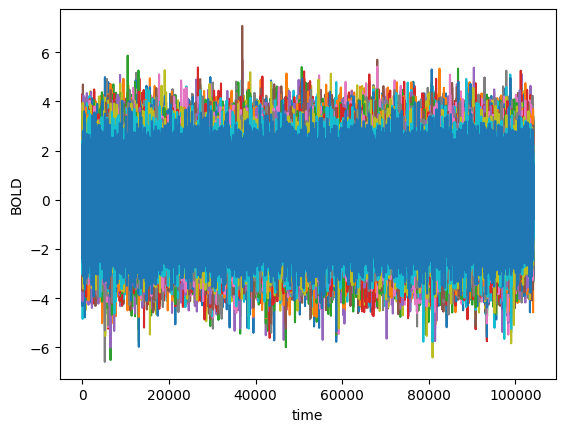

In [14]:
# EVALUATING PCA
# Concatenate all signals from all subjects along the time axis
concatenated_signals_list = []
avg_activity = []
for sig in collected_signals_sel:
    #sig = np.copy(sig)[5:,:]
    #sig_centered = sig - np.mean(sig)
    #sig_centered = sig_centered - np.mean(sig_centered, axis=1, keepdims=True)
    #concatenated_signals_list.append(sig_centered.T)
    concatenated_signals_list.append(sig.T)
    avg_activity.append(np.mean(sig, axis=0))
    
concatenated_signals = np.concatenate(concatenated_signals_list, axis=1)


TIMES = concatenated_signals.shape[1]
data = np.copy(concatenated_signals) #
#data=values[ch,:].T

mean = np.mean(data, axis=1)
std_data = np.std(data, axis=1)

centered_data = (data - np.tile(mean,(TIMES,1) ).T)/np.tile(std_data,(TIMES,1) ).T

plt.plot(centered_data.T)
plt.xlabel('time')

plt.ylabel('BOLD')


plt.show()

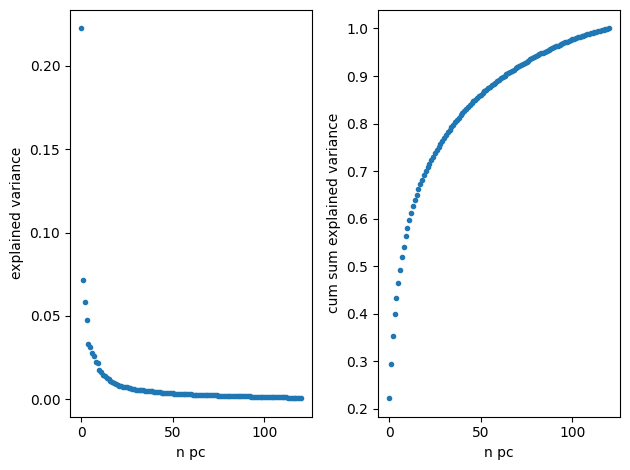

In [15]:
# Step 2: Compute the covariance matrix
covariance_matrix = np.cov(centered_data.T, rowvar=False)

# Step 3: Perform eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Step 4: Sort eigenvalues and eigenvectors in descending order

sorted_indices_common = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues_common = eigenvalues[sorted_indices_common]
sorted_eigenvectors_common = eigenvectors[:, sorted_indices_common]

# Step 5: Calculate the principal components
principal_components_common = np.dot(centered_data.T, sorted_eigenvectors_common)

plt.subplot(121)
plt.plot(explained_variance_ratio[sorted_indices_common],'.')
plt.xlabel('n pc')
plt.ylabel('explained variance')

plt.subplot(122)

plt.plot(np.cumsum(explained_variance_ratio[sorted_indices_common]),'.')
plt.xlabel('n pc')
plt.ylabel('cum sum explained variance')

plt.tight_layout()

#concatenated_signals = np.copy(principal_components[:50,:])

N_sites,TIMES = np.shape(concatenated_signals)
trial_duration = TIMES

# Step 2: Compute the covariance matrix
centered_data = np.copy(np.double(concatenated_signals)).T
#covariance_matrix = np.cov( np.double(centered_data) , rowvar=False

dt = 0.005

norm_mua_target_tot = np.copy(centered_data)
norm_mua_target = np.copy(centered_data)


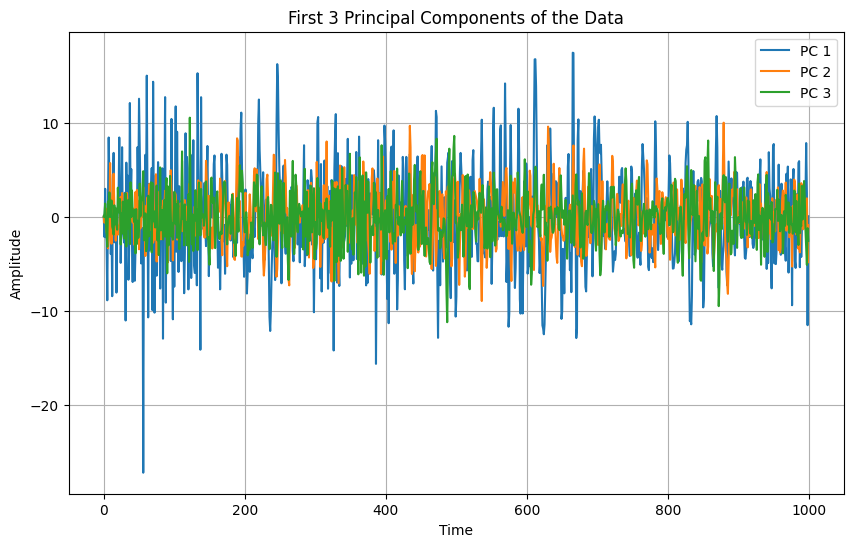

In [16]:
plt.figure(figsize=(10, 6))

# Plot the first 3 principal components
for i in range(3):
    plt.plot(principal_components_common[:1000, i], label=f'PC {i+1}')


plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('First 3 Principal Components of the Data')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def train_test_pinv(feedback_factor=10.,sigma_inner_dynamics=0.):

    res_activity_collection = []
    mua_activity_collection = []

    cue_weight = 1.*input_factor
    couple_weight = 1.*input_factor
    mua_relative_weight = feedback_factor
    
    S = []
    V = []

    S_res = []
    V_res = []

    INP = []
    
    network_reservoire.acc=0

    if_driven=True

    for time in range(network_reservoire.T-1):

        feedback = np.copy(network_reservoire.y)#np.copy(principal_components_S)##
        
        if if_driven:
            feedback = np.copy(norm_mua_target[:,time])

        input = np.copy( mua_relative_weight*feedback )
        
        network_reservoire.step_rate (input,  sigma_dyn = sigma_inner_dynamics)

        INP.append(input)

        S_res.append(network_reservoire.X)
        #S.append(network.S)
        S.append(network_reservoire.y[:])

        V_res.append(network_reservoire.X)
        #BEHAVIOR.append(network.y)
        
       
        res_activity_collection.append(network_reservoire.X )
        mua_activity_collection.append((np.array(norm_mua_target[:,time])))
    
    print(np.shape(res_activity_collection),np.shape(mua_activity_collection))

    return res_activity_collection,mua_activity_collection


In [18]:
def train_test(n_Rep, if_collect = True, sigma_noise_dyn=0, sigma_inner_dynamics=0, feedback_factor=10.,if_plot_results=False,if_use_reservoir = True, perturbation = None):
    
    ERROR = []
    ERROR_BEHAVIOR = []
    ERROR_PCA = []
    ERROR_S_PCA = []
    ERROR_BEHAVIOR_NET = []

    cue_weight = 1.*input_factor
    couple_weight = 1.*input_factor
    #mua_relative_weight = 1.
    mua_relative_weight = feedback_factor

    for epoch in range(n_Rep):
        
        network_reservoire.reset()
            
        if_driven = True
        behavior_direction = np.sign(1)#-1 left, 1 right

        
        data = np.copy(norm_mua_target.T)
        centered_data = np.copy(data)# - mean
        principal_components_data= np.dot(centered_data, sorted_eigenvectors_common)
            
        if if_collect:

            S = []
            S_fromres = []
            V = []
            S_res = []
            V_res = []

            INP = []
            BEHAVIOR = []
            BEHAVIOR_TARG = []
            BEHAVIOR_NET = []
            BEHAVIOR_ACC = []
            
            PCA = []

        Err = 0
        Err_out = 0
        Err_pca = 0
        Err_out_net = 0
        Err_S_pca = 0
        
       
        accumulation_res=0
        network_reservoire.acc=0
    
        for time in range(trial_duration-1):

            behavior_direction = np.sign(1.)#-1 left, 1 right
            
            target_behavior = np.zeros((1,))
            target_behavior = behavior_direction*np.heaviside(1.,0.)
    
            if time > 5:
                #print(time)
                if_driven=False
            
                
            
            feedback = np.copy(network_reservoire.y)#np.copy(principal_components_S)##
            
            if if_driven:
                feedback = np.copy(norm_mua_target[:,time])

            input = np.copy(mua_relative_weight*feedback)   
            
            network_reservoire.step_rate (input, sigma_dyn=sigma_inner_dynamics)

            if sigma_noise_dyn>0.:
                network_reservoire.y += np.random.normal(0,sigma_noise_dyn,size= (N_sites,))
            

            if perturbation:
                network_reservoire.y = (1-network_reservoire.alpha)*network_reservoire.y + network_reservoire.alpha*(network_reservoire.J_targ)@network_reservoire.X
            

            if if_collect:

                INP.append(input)

                S_res.append(network_reservoire.X)
                S_fromres.append(network_reservoire.y)
                V_res.append(network_reservoire.X)

                BEHAVIOR_ACC.append(accumulation_res)
                PCA.append(network_reservoire.y)
                BEHAVIOR_TARG.append(target_behavior)
      
        ERROR.append(Err)
        ERROR_BEHAVIOR.append(Err_out)
        
        ERROR_S_PCA.append(Err_S_pca)
        
        ERROR_PCA.append(Err_pca)

    if if_plot_results:

        data = np.copy(norm_mua_target.T)
        #mean = np.mean(data, axis=0)
        centered_data = np.copy(data)# - mean
        principal_components_data= np.dot(centered_data, sorted_eigenvectors_common)
        
        data = np.array(S_fromres)
        #mean = np.mean(data, axis=0)
        centered_data = np.copy(data)# - mean
        principal_components= np.dot(centered_data, sorted_eigenvectors_common)

        
        fig,axs = plt.subplots(2,3,figsize=(10,5))

        axs[0,0].imshow(np.array(INP)[:,:15].T,aspect='auto',cmap='copper',extent=[0, np.shape(np.array(INP))[0]*dt, 0, 15])
        axs[0,0].set_title('input')
         
        axs[0,2].set_title('output')
        axs[0,2].legend()
        
        axs[1,0].plot(np.arange(np.shape(np.array(principal_components_data))[0])*dt,principal_components_data[:,0],label='data')
        axs[1,0].plot(np.arange(np.shape(np.array(principal_components))[0])*dt,principal_components[:,0],label='model')
        
        #axs[1,0].plot(np.arange(np.shape(np.array(principal_components_res))[0])*dt,principal_components_res[:,0],label='data')
        
        axs[1,0].set_xlabel('time (s)')
        axs[1,0].set_ylabel('PC 1')
        axs[1,1].set_xlabel('time (s)')
        axs[1,1].set_ylabel('PC 2')
        axs[1,2].set_xlabel('time (s)')
        axs[1,2].set_ylabel('PC 3')

        axs[1,1].plot(np.arange(np.shape(np.array(principal_components_data))[0])*dt,principal_components_data[:,1],label='data')
        axs[1,1].plot(np.arange(np.shape(np.array(principal_components))[0])*dt,principal_components[:,1],label='model')
        #axs[1,1].plot(np.arange(np.shape(np.array(principal_components_res))[0])*dt,principal_components_res[:,1],label='data')
        

        axs[1,2].plot(np.arange(np.shape(np.array(principal_components_data))[0])*dt,principal_components_data[:,2],label='data')
        axs[1,2].plot(np.arange(np.shape(np.array(principal_components))[0])*dt,principal_components[:,2],label='model')
        #axs[1,2].plot(np.arange(np.shape(np.array(principal_components_res))[0])*dt,principal_components_res[:,2],label='data')

        axs[1,0].legend()
        axs[1,1].legend()
        axs[1,2].legend()
        
        plt.tight_layout()
        
        plt.savefig('fig.eps')
        plt.savefig('fig.png')
        
        plt.show()
        
    if if_use_reservoir == True:
        data = np.copy(np.array(S_fromres))
    else:
        data = np.copy(np.array(S))

    centered_data = np.copy(data)# - mean
    principal_components= np.dot(centered_data, sorted_eigenvectors_common)
    
    data = np.copy(norm_mua_target.T)
    centered_data = np.copy(data)# - mean
    principal_components_data= np.dot(centered_data, sorted_eigenvectors_common)

    network_reservoire.data = np.copy(np.array( S_fromres ))
    network_reservoire.principal_components = np.array(principal_components)
    network_reservoire.principal_components_data = np.array(principal_components_data)

    
    return np.mean(ERROR),np.mean(ERROR_BEHAVIOR),np.mean(ERROR_PCA),np.mean(ERROR_BEHAVIOR_NET),np.mean(ERROR_S_PCA)


In [19]:
spectral_radius = .95

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


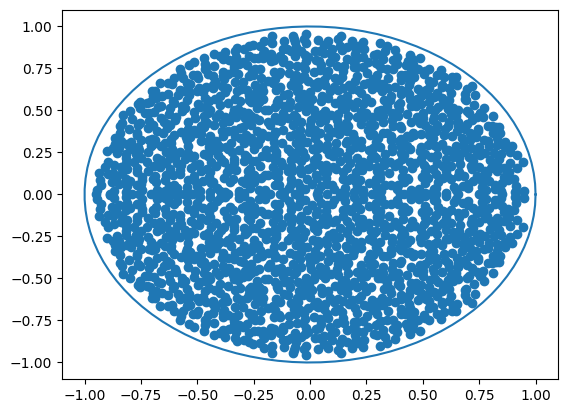

In [20]:
import gym
import numpy as np
from copy import deepcopy
from tqdm import trange
from matplotlib import pyplot as plt
from matplotlib.animation import ArtistAnimation
from gym.envs.mujoco import AntEnv  # Assuming you're using MuJoCo's Ant environment


from scipy.stats import pearsonr
import pickle

#network_reservoire.J = (network_reservoire.J + network_reservoire.J.T)/2./np.sqrt(2.)

if_save_res = True
if_load_res = False
N_PC = 20 # Number of principal components to use
N_sites = 121 # Number of sites in the Schaefer atlas

trial_duration = 139

N, I, O, TIME = 2000, N_sites, N_sites , 600
shape = (N, I, O, TIME)

dt = .005# / T;

tau_m_f = .0001 * dt
tau_m_s = .0001 * dt
sigma_input = .01

n_electrodes = N_sites
n_pca = n_electrodes

# Here we build the dictionary of the simulation parameters
par = {'tau_m_f' : tau_m_f,'tau_m_s' : tau_m_s,
    'N' : N, 'T' : TIME, 'dt' : dt,
    'sigma_input' : sigma_input, 'shape' : shape}
n_pca_feedback = N_sites#3#only

shape = ( N , n_pca_feedback, N_sites, TIME)
par['shape']=shape

network_reservoire = RESERVOIRE_SIMPLE(par)

if if_save_res:
    with open('network_reservoire.pkl', 'wb') as f:
        pickle.dump(network_reservoire, f)

if if_load_res:
    with open('network_reservoire.pkl', 'rb') as f:
        network_reservoire = pickle.load(f)

network_reservoire.J = network_reservoire.J * spectral_radius

eigenvalues, eigenvectors = np.linalg.eig(network_reservoire.J)

real_parts = np.real(eigenvalues)
imaginary_parts = np.imag(eigenvalues)

# Create a scatter plot
plt.scatter(real_parts, imaginary_parts)

theta = np.linspace(0, 2 * np.pi, 100)

# Circle center coordinates
center = (0, 0)
# Circle radius
radius = 1.

# Calculate circle points
x = center[0] + radius * np.cos(theta)
y = center[1] + radius * np.sin(theta)

# Plot the circle
plt.plot(x, y)

err_collected = []

In [21]:
len(concatenated_signals_list)

702

In [22]:
# Initialize storage for fitted weights
fitted_weights = {}

trial_duration = 139

fitted_weights_list = []
FC_SIM_COLLECTED = []
X_coll = []
Y_coll = []

means = []

all_weights = []

detrended_means = []
FC_degree_collected = []

FC_plus_collected_sel = []
FC_plus_collected_sel_sim = []

FC_collected = []

Y_coll_sim = []
ccs_orig = []

# Perform 10 trials per dataset
for patient in trange(len(concatenated_signals_list)):

    data = np.copy(concatenated_signals_list[patient]) # Use the first run of the patient data
    #data = data - np.mean(data, axis=1, keepdims=True) 
    network_reservoire.T = np.shape(data)[1]  # Set the trial duration based on the data shape
    network_reservoire.reset()  # Reset the reservoir network for each patient

    #norm_mua_target = np.copy(data)
    # Remove PC1 as detrending
    u, s, vt = np.linalg.svd(data - np.mean(data, axis=1, keepdims=True), full_matrices=False)
    pc1 = np.outer(u[:, 0], s[0] * vt[0, :])
    norm_mua_target = np.copy(data)# - pc1)
    # Project onto first 5 principal components only
    #norm_mua_target = np.dot(norm_mua_target.T, sorted_eigenvectors[:, :N_PC]).T
    detrended_means.append(np.mean(norm_mua_target, axis=1, keepdims=True))

    eigenvectors_5 = sorted_eigenvectors_common[:, 0:N_PC_MODEL]
    
    # Step 1: project onto the first 5 PCs
    pc_5_scores = np.dot(data.T, eigenvectors_5)
    # Step 2: reconstruct (reproject back)
    norm_mua_target = np.dot(pc_5_scores, eigenvectors_5.T).T

    # Z-score normalization
    #norm_mua_target = (norm_mua_target - np.mean(norm_mua_target, axis=1, keepdims=True)) / np.std(norm_mua_target, axis=1, keepdims=True)
    #norm_mua_target = (norm_mua_target - np.mean(norm_mua_target, axis=1, keepdims=True)) / np.std(norm_mua_target, axis=1, keepdims=True)
    fc_matrix = np.corrcoef(norm_mua_target)
    fc_matrix = np.nan_to_num(fc_matrix)   
    FC_collected.append(fc_matrix.flatten())
    FC_degree_collected.append(np.sum(np.corrcoef(norm_mua_target),axis=1))

    fc_matrix_delayed = np.corrcoef(norm_mua_target.T[:-1,:].T, norm_mua_target.T[1:,:].T)
    fc_matrix_delayed = np.nan_to_num(fc_matrix_delayed)
    fc_delayed_flat = fc_matrix_delayed[121:,:121]

    # Concatenate both flattened arrays
    fc_features = np.concatenate([fc_matrix.flatten(), fc_delayed_flat.flatten()])

    #print(np.shape(fc_features))

    FC_plus_collected_sel.append(fc_features)
    
    means.append(np.mean(data, axis=1, keepdims=True))
    weights_list = []
    

    X, Y = train_test_pinv(feedback_factor=recurrent_factor)

    X = np.array(X)[10:,:]
    Y = np.array(Y)[10:,:]
    
    Y_coll.append(Y)
    X_coll.append(X)
    weights_list_mean=[]
    
    noise_size = .025
        
    W_out = np.linalg.pinv(X + np.random.normal(0, noise_size, size=np.shape(X))).dot(Y)
    mse = np.mean((Y - np.dot(X, W_out))**2)
    print(mse)

    weights_list.append(W_out)
    all_weights.append(W_out.flatten())
    fitted_weights[patient] = weights_list
    fitted_weights_list.append(W_out)
    network_reservoire.Jout = np.copy(W_out.T)
    err,err_out,err_pca,_,err_spca = train_test(1,sigma_noise_dyn=0.1,feedback_factor=recurrent_factor,if_plot_results=False)

    fc_sim_data = np.corrcoef(network_reservoire.data.T)
    fc_sim_data = np.nan_to_num(fc_sim_data)
    FC_SIM_COLLECTED.append(fc_sim_data.flatten())

    fc_matrix_delayed_sim = np.corrcoef(network_reservoire.data[:-1,:].T, network_reservoire.data[1:,:].T)
    fc_matrix_delayed_sim = np.nan_to_num(fc_matrix_delayed_sim)
    fc_delayed_flat = fc_matrix_delayed_sim[121:,:121]

    # Concatenate both flattened arrays
    fc_features = np.concatenate([fc_sim_data.flatten(), fc_delayed_flat.flatten()])

    FC_plus_collected_sel_sim.append(fc_features)

    print(np.corrcoef(FC_SIM_COLLECTED[-1],FC_collected[-1])[0,1])
    ccs_orig.append(np.corrcoef(FC_SIM_COLLECTED[-1],FC_collected[-1])[0,1])

    
    


  0%|          | 0/702 [00:00<?, ?it/s]c:\Users\user\Desktop\2026.AD_MotionCorrection\bids_env\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\user\Desktop\2026.AD_MotionCorrection\bids_env\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 2/702 [00:00<01:25,  8.22it/s]

(139, 2000) (139, 121)
0.10447201339295603
0.8072428583967987
(139, 2000) (139, 121)
0.0729241854019897
0.8108749817575188


  1%|          | 4/702 [00:00<01:23,  8.32it/s]

(139, 2000) (139, 121)
0.10718610985422078
0.7767648675775032
(139, 2000) (139, 121)
0.06849725067740241
0.8145351576222234


  1%|          | 5/702 [00:00<01:23,  8.39it/s]

...

(199, 2000) (199, 121)
0.07498687181362548
0.6722668113548272
(139, 2000) (139, 121)
0.07248169146171818
0.7467758209434285


100%|█████████▉| 701/702 [01:27<00:00,  8.15it/s]

(139, 2000) (139, 121)
0.07243380026231122
0.7522751437445865
(139, 2000) (139, 121)
0.0707349274675037
0.6790039826888051


100%|██████████| 702/702 [01:27<00:00,  8.02it/s]

(139, 2000) (139, 121)
0.06672955395052953
0.7333921661048863


C:\Users\user\AppData\Local\Temp\ipykernel_22652\120753076.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,2].legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


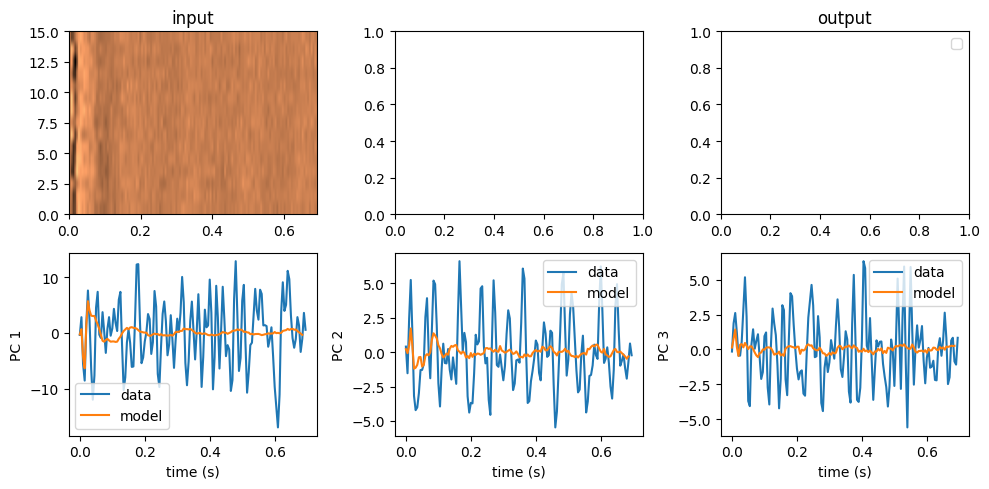

In [23]:
err,err_out,err_pca,_,err_spca = train_test(1,sigma_noise_dyn=0.1,feedback_factor=recurrent_factor,if_plot_results=True)


Scanning K_PC...


100%|██████████| 6/6 [01:44<00:00, 17.47s/it]



Auto-selected K_PC = 150  (projection cost = -1.70e-09  vs threshold 7.13e-04)


Projecting with K_PC_auto: 100%|██████████| 702/702 [00:17<00:00, 40.83it/s]



Scanning M (number of archetypes)...


100%|██████████| 5/5 [01:07<00:00, 13.43s/it]


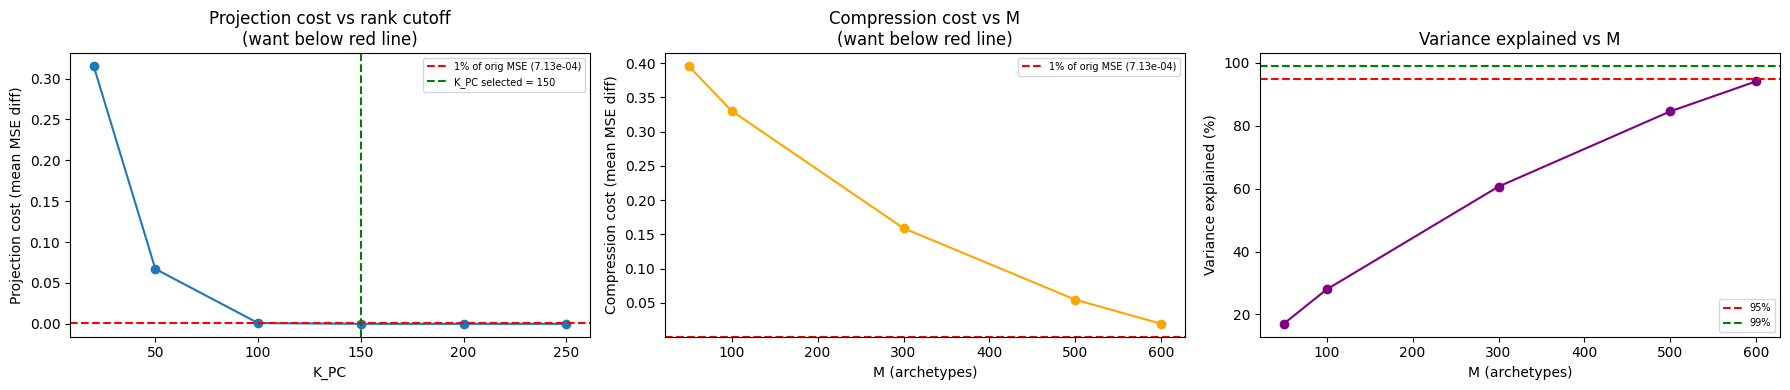


Summary:
  Original MSE:    0.0713
  Projected MSE:   0.0713  (cost: -1.70e-09)
  M= 50:  compression cost=3.96e-01  var_exp=17.0%
  M=100:  compression cost=3.30e-01  var_exp=27.9%
  M=300:  compression cost=1.59e-01  var_exp=60.7%
  M=500:  compression cost=5.45e-02  var_exp=84.6%
  M=600:  compression cost=1.93e-02  var_exp=94.1%


In [ ]:
if_explore_parameters = True
if if_explore_parameters:

    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    from tqdm import tqdm

    all_ids = list(range(len(X_coll)))

    # ============================================================
    # Scan 1 — find the right K_PC by checking projection cost
    #          as a function of rank cutoff
    # ============================================================

    K_candidates = [20, 50, 100, 150, 200, 250 ]

    mse_original = []
    for pid in all_ids:
        X   = np.array(X_coll[pid],              dtype=np.float64)
        Y   = np.array(Y_coll[pid],              dtype=np.float64)
        W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T
        mse_original.append(np.mean((Y - X @ W_i.T) ** 2))
    mse_original = np.array(mse_original)

    proj_costs = []   # mean(mse_proj - mse_orig) for each K

    print("Scanning K_PC...")
    for K in tqdm(K_candidates):
        mse_proj_k = []
        for pid in all_ids:
            X   = np.array(X_coll[pid],              dtype=np.float64)
            Y   = np.array(Y_coll[pid],              dtype=np.float64)
            W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T

            _, s, Vt = np.linalg.svd(X, full_matrices=False)
            k        = min(K, np.sum(s > 1e-8))
            Vt_k     = Vt[:k]
            W_proj   = W_i @ Vt_k.T @ Vt_k
            mse_proj_k.append(np.mean((Y - X @ W_proj.T) ** 2))

        proj_costs.append(np.mean(np.array(mse_proj_k) - mse_original))

    # ============================================================
    # Scan 2 — find the right M by checking compression cost
    #          for the best K_PC found above
    # ============================================================

    # Pick K_PC where projection cost has saturated (< 1% of original)
    threshold_proj = 0.01 * mse_original.mean()
    K_PC_auto = K_candidates[next(
        (i for i, c in enumerate(proj_costs) if c < threshold_proj),
        -1   # fallback to largest if none found
    )]
    print(f"\nAuto-selected K_PC = {K_PC_auto}  "
        f"(projection cost = {proj_costs[K_candidates.index(K_PC_auto)]:.2e}  "
        f"vs threshold {threshold_proj:.2e})")

    # Recompute projections with K_PC_auto
    W_proj_list, Vt_list = [], []
    for pid in tqdm(all_ids, desc="Projecting with K_PC_auto"):
        X   = np.array(X_coll[pid],              dtype=np.float64)
        W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T
        _, s, Vt = np.linalg.svd(X, full_matrices=False)
        k        = min(K_PC_auto, np.sum(s > 1e-8))
        Vt_k     = Vt[:k]
        W_proj_list.append((W_i @ Vt_k.T @ Vt_k).flatten())
        Vt_list.append(Vt_k)

    W_stack    = np.stack(W_proj_list)
    W_mean     = W_stack.mean(axis=0, keepdims=True)
    W_centered = W_stack - W_mean
    U_s, S_s, Vt_s = np.linalg.svd(W_centered, full_matrices=False)

    M_candidates  = [  50 , 100, 300,500,600 ]
    comp_costs    = []
    var_exp_curve = []

    N_out = np.array(fitted_weights_list[0]).shape[1]
    N_in  = np.array(fitted_weights_list[0]).shape[0]

    mse_projected = []
    for idx, pid in enumerate(all_ids):
        X     = np.array(X_coll[pid], dtype=np.float64)
        Y     = np.array(Y_coll[pid], dtype=np.float64)
        W_proj = W_proj_list[idx].reshape(N_out, N_in)
        mse_projected.append(np.mean((Y - X @ W_proj.T) ** 2))
    mse_projected = np.array(mse_projected)

    print("\nScanning M (number of archetypes)...")
    for M in tqdm(M_candidates):
        archetypes = Vt_s[:M]
        G_scores   = U_s[:, :M] * S_s[:M]
        W_mean_t   = torch.tensor(W_mean.reshape(N_out, N_in), dtype=torch.float32)
        W_fixed    = torch.tensor(archetypes.reshape(M, N_out, N_in), dtype=torch.float32)

        mse_arch_m = []
        for idx, pid in enumerate(all_ids):
            X   = torch.tensor(X_coll[pid], dtype=torch.float32)
            Y   = torch.tensor(Y_coll[pid], dtype=torch.float32)
            g   = torch.tensor(G_scores[idx], dtype=torch.float32)
            W_g = (g[:, None, None] * W_fixed).sum(0) + W_mean_t
            mse_arch_m.append(((Y - X @ W_g.T) ** 2).mean().item())

        comp_costs.append(np.mean(np.array(mse_arch_m) - mse_projected))
        var_exp_curve.append((S_s[:M] ** 2).sum() / (S_s ** 2).sum())

    # ============================================================
    # Plots
    # ============================================================

    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    # Panel 0 — projection cost vs K_PC
    ax[0].plot(K_candidates, proj_costs, '-o')
    ax[0].axhline(threshold_proj, color='red', linestyle='--',
                label=f'1% of orig MSE ({threshold_proj:.2e})')
    ax[0].axvline(K_PC_auto, color='green', linestyle='--',
                label=f'K_PC selected = {K_PC_auto}')
    ax[0].set_xlabel("K_PC"); ax[0].set_ylabel("Projection cost (mean MSE diff)")
    ax[0].set_title("Projection cost vs rank cutoff\n(want below red line)")
    ax[0].legend(fontsize=7)

    # Panel 1 — compression cost vs M
    ax[1].plot(M_candidates, comp_costs, '-o', color='orange')
    ax[1].axhline(threshold_proj, color='red', linestyle='--',
                label=f'1% of orig MSE ({threshold_proj:.2e})')
    ax[1].set_xlabel("M (archetypes)"); ax[1].set_ylabel("Compression cost (mean MSE diff)")
    ax[1].set_title("Compression cost vs M\n(want below red line)")
    ax[1].legend(fontsize=7)

    # Panel 2 — variance explained vs M
    ax[2].plot(M_candidates, np.array(var_exp_curve) * 100, '-o', color='purple')
    ax[2].axhline(95, color='red', linestyle='--', label='95%')
    ax[2].axhline(99, color='green', linestyle='--', label='99%')
    ax[2].set_xlabel("M (archetypes)"); ax[2].set_ylabel("Variance explained (%)")
    ax[2].set_title("Variance explained vs M")
    ax[2].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    print(f"\nSummary:")
    print(f"  Original MSE:    {mse_original.mean():.4f}")
    print(f"  Projected MSE:   {mse_projected.mean():.4f}  "
        f"(cost: {(mse_projected-mse_original).mean():.2e})")
    for M, cc, ve in zip(M_candidates, comp_costs, var_exp_curve):
        print(f"  M={M:3d}:  compression cost={cc:.2e}  var_exp={ve*100:.1f}%")

(array([  1.,   3.,  10.,  38., 104., 148., 185., 125.,  79.,   9.]),
 array([0.49031309, 0.53495276, 0.57959244, 0.62423211, 0.66887178,
        0.71351145, 0.75815112, 0.80279079, 0.84743047, 0.89207014,
        0.93670981]),
 <BarContainer object of 10 artists>)

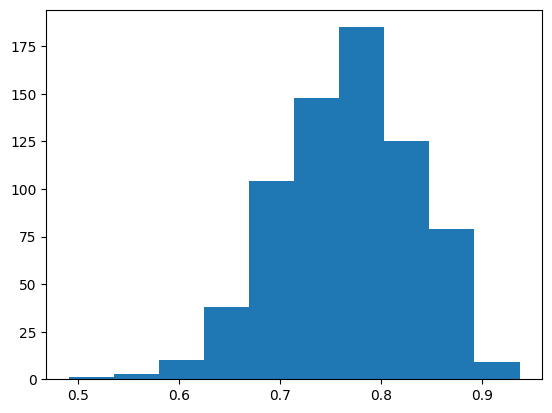

In [25]:
plt.hist(ccs_orig)

Step 1 — projecting W_i onto row space of X_i...


100%|██████████| 702/702 [00:17<00:00, 39.30it/s]



Step 3 — computing archetype MSE in Y space...


100%|██████████| 702/702 [00:30<00:00, 22.75it/s]



MSE original   (W_i @ X vs Y)          — mean: 0.0713  std: 0.0077
MSE projected  (W_proj @ X vs Y)        — mean: 0.0713  std: 0.0077
MSE archetype  (W_g @ X vs Y, M=700)    — mean: 0.0713  std: 0.0077

Projection cost (proj - orig):           mean: -4.12e-18
Compression cost (arch - proj):           mean: -2.71e-06
Total cost (arch - orig):                 mean: -2.71e-06


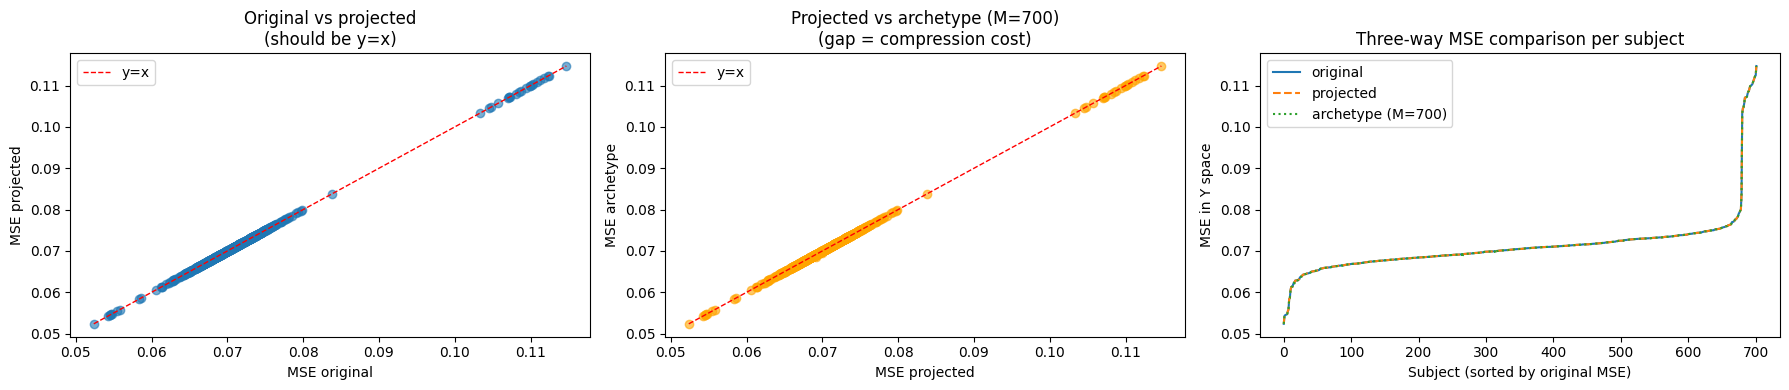

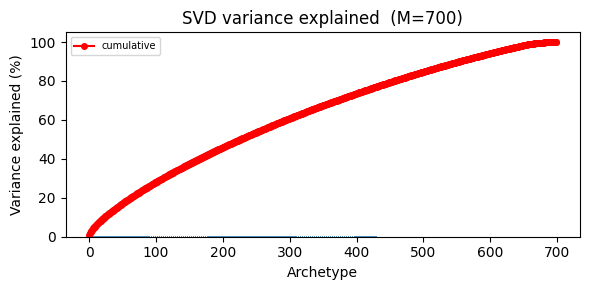

In [26]:
import numpy as np
import torch
import torch.linalg as LA
import matplotlib.pyplot as plt
from tqdm import tqdm

K_PC    = 200
M       = 700
all_ids = list(range(len(X_coll)))

W_proj_list = []
Vt_list     = []

mse_original  = []
mse_projected = []

print("Step 1 — projecting W_i onto row space of X_i...")
for idx, pid in enumerate(tqdm(all_ids)):
    X   = np.array(X_coll[pid],              dtype=np.float64)
    Y   = np.array(Y_coll[pid],              dtype=np.float64)
    W_i = np.array(fitted_weights_list[pid], dtype=np.float64).T  # [N_out, N_in]

    _, s, Vt = np.linalg.svd(X, full_matrices=False)
    k        = min(K_PC, np.sum(s > 1e-8))
    Vt_k     = Vt[:k]

    W_proj = W_i @ Vt_k.T @ Vt_k          # [N_out, N_in]

    Y_orig = X @ W_i.T
    Y_proj = X @ W_proj.T

    mse_original.append( np.mean((Y - Y_orig) ** 2))
    mse_projected.append(np.mean((Y - Y_proj) ** 2))

    W_proj_list.append(W_proj.flatten())
    Vt_list.append(Vt_k)

mse_original  = np.array(mse_original)
mse_projected = np.array(mse_projected)

# ============================================================
# Step 2 — SVD of projected weights → archetypes + G scores
# ============================================================

W_stack    = np.stack(W_proj_list)
W_mean     = W_stack.mean(axis=0, keepdims=True)
W_centered = W_stack - W_mean

U_s, S_s, Vt_s = np.linalg.svd(W_centered, full_matrices=False)

archetypes = Vt_s[:M]               # [M, N_out*N_in]
G_scores   = U_s[:, :M] * S_s[:M]  # [P, M]

var_explained = (S_s[:M] ** 2) / (S_s ** 2).sum()

W_out_shape = (np.array(fitted_weights_list[0]).shape[1],   # N_out
               np.array(fitted_weights_list[0]).shape[0])   # N_in
N_out, N_in = W_out_shape

W_fixed  = torch.tensor(archetypes.reshape(M, N_out, N_in), dtype=torch.float32)
W_mean_t = torch.tensor(W_mean.reshape(N_out, N_in),        dtype=torch.float32)

# ============================================================
# Step 3 — Compute all three MSEs per subject
# ============================================================

mse_archetype = []

print("\nStep 3 — computing archetype MSE in Y space...")
for idx, pid in enumerate(tqdm(all_ids)):
    X   = torch.tensor(X_coll[pid],              dtype=torch.float32)
    Y   = torch.tensor(Y_coll[pid],              dtype=torch.float32)

    g   = torch.tensor(G_scores[idx],            dtype=torch.float32)   # [M]
    W_g = (g[:, None, None] * W_fixed).sum(0) + W_mean_t               # [N_out, N_in]

    Y_hat = X @ W_g.T                                                   # [T, N_out]
    mse_archetype.append(((Y - Y_hat) ** 2).mean().item())

mse_archetype = np.array(mse_archetype)

# ============================================================
# Summary
# ============================================================

print(f"\nMSE original   (W_i @ X vs Y)          — mean: {mse_original.mean():.4f}  std: {mse_original.std():.4f}")
print(f"MSE projected  (W_proj @ X vs Y)        — mean: {mse_projected.mean():.4f}  std: {mse_projected.std():.4f}")
print(f"MSE archetype  (W_g @ X vs Y, M={M})    — mean: {mse_archetype.mean():.4f}  std: {mse_archetype.std():.4f}")
print(f"\nProjection cost (proj - orig):           mean: {(mse_projected - mse_original).mean():.2e}")
print(f"Compression cost (arch - proj):           mean: {(mse_archetype - mse_projected).mean():.2e}")
print(f"Total cost (arch - orig):                 mean: {(mse_archetype - mse_original).mean():.2e}")

# ============================================================
# Plots
# ============================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

# Panel 0 — scatter: original vs projected (should be y=x)
ax[0].scatter(mse_original, mse_projected, alpha=0.6)
lims = [min(mse_original.min(), mse_projected.min()),
        max(mse_original.max(), mse_projected.max())]
ax[0].plot(lims, lims, 'r--', linewidth=1, label='y=x')
ax[0].set_xlabel("MSE original"); ax[0].set_ylabel("MSE projected")
ax[0].set_title("Original vs projected\n(should be y=x)")
ax[0].legend()

# Panel 1 — scatter: projected vs archetype (compression cost)
ax[1].scatter(mse_projected, mse_archetype, alpha=0.6, color='orange')
lims = [min(mse_projected.min(), mse_archetype.min()),
        max(mse_projected.max(), mse_archetype.max())]
ax[1].plot(lims, lims, 'r--', linewidth=1, label='y=x')
ax[1].set_xlabel("MSE projected"); ax[1].set_ylabel("MSE archetype")
ax[1].set_title(f"Projected vs archetype (M={M})\n(gap = compression cost)")
ax[1].legend()

# Panel 2 — all three per subject sorted by original MSE
sort_idx = np.argsort(mse_original)
x        = np.arange(len(all_ids))
ax[2].plot(x, mse_original[sort_idx],  '-',  label='original',  linewidth=1.5)
ax[2].plot(x, mse_projected[sort_idx], '--', label='projected',  linewidth=1.5)
ax[2].plot(x, mse_archetype[sort_idx], ':',  label=f'archetype (M={M})', linewidth=1.5)
ax[2].set_xlabel("Subject (sorted by original MSE)")
ax[2].set_ylabel("MSE in Y space")
ax[2].set_title("Three-way MSE comparison per subject")
ax[2].legend()

plt.tight_layout()
plt.show()

# Bonus — variance explained curve (how many archetypes are enough?)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(M), var_explained * 100, alpha=0.8)
ax.plot(range(M), np.cumsum(var_explained) * 100,
        '-o', color='red', markersize=4, label='cumulative')
ax.set_xlabel("Archetype"); ax.set_ylabel("Variance explained (%)")
ax.set_title(f"SVD variance explained  (M={M})")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [27]:
# Initialize storage

ccs_reduced = []

fitted_weights = {}
trial_duration = 139
fitted_weights_list = []
FC_SIM_COLLECTED = []
X_coll = []
Y_coll = []
means = []
all_weights = []
detrended_means = []
FC_degree_collected = []
FC_plus_collected_sel = []
FC_plus_collected_sel_sim = []
FC_collected = []
Y_coll_sim = []

# W_fixed   [M, N_out, N_in]  — archetypes from SVD
# W_mean_t  [N_out, N_in]     — population mean weight
# G_scores  [P, M]            — per-subject mixing coordinates

W_mean_t = torch.tensor(W_mean.reshape(N_out, N_in), dtype=torch.float32)

for patient in range(len(concatenated_signals_list)):

    data = np.copy(concatenated_signals_list[patient])
    network_reservoire.T = np.shape(data)[1]
    network_reservoire.reset()

    u, s, vt = np.linalg.svd(data - np.mean(data, axis=1, keepdims=True), full_matrices=False)
    norm_mua_target = np.copy(data)
    detrended_means.append(np.mean(norm_mua_target, axis=1, keepdims=True))

    eigenvectors_5   = sorted_eigenvectors_common[:, 0:N_PC_MODEL]
    pc_5_scores      = np.dot(data.T, eigenvectors_5)
    norm_mua_target  = np.dot(pc_5_scores, eigenvectors_5.T).T

    fc_matrix = np.nan_to_num(np.corrcoef(norm_mua_target))
    FC_collected.append(fc_matrix.flatten())
    FC_degree_collected.append(np.sum(fc_matrix, axis=1))

    fc_matrix_delayed = np.nan_to_num(
        np.corrcoef(norm_mua_target.T[:-1, :].T, norm_mua_target.T[1:, :].T))
    fc_delayed_flat   = fc_matrix_delayed[121:, :121]
    fc_features       = np.concatenate([fc_matrix.flatten(), fc_delayed_flat.flatten()])
    print(np.shape(fc_features))
    FC_plus_collected_sel.append(fc_features)

    means.append(np.mean(data, axis=1, keepdims=True))

    X, Y = train_test_pinv(feedback_factor=recurrent_factor)
    X = np.array(X)[10:, :]
    Y = np.array(Y)[10:, :]
    X_coll.append(X)
    Y_coll.append(Y)

    # ── Archetype reconstruction ──────────────────────────────
    g_i = torch.tensor(G_scores[patient], dtype=torch.float32)      # [M]
    W_i = (g_i[:, None, None] * W_fixed).sum(0) + W_mean_t          # [N_out, N_in]
    W_out = W_i.T.detach().cpu().numpy()                             # [N_in, N_out]
    # ─────────────────────────────────────────────────────────

    network_reservoire.Jout = np.copy(W_out.T)
    err, err_out, err_pca, _, err_spca = train_test(
        1, sigma_noise_dyn=0.1,
        feedback_factor=recurrent_factor,
        if_plot_results=False,
    )

    fc_sim_data = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
    FC_SIM_COLLECTED.append(fc_sim_data.flatten())
    Y_coll_sim.append(network_reservoire.data.T)

    fc_matrix_delayed_sim = np.nan_to_num(
        np.corrcoef(network_reservoire.data[:-1, :].T,
                    network_reservoire.data[1:,  :].T))
    fc_delayed_flat_sim   = fc_matrix_delayed_sim[121:, :121]
    fc_features_sim       = np.concatenate([fc_sim_data.flatten(),
                                            fc_delayed_flat_sim.flatten()])
    FC_plus_collected_sel_sim.append(fc_features_sim)

    fitted_weights_list.append(W_out)
    fitted_weights[patient] = W_out

    r = np.corrcoef(FC_SIM_COLLECTED[-1], FC_collected[-1])[0, 1]
    print(f"patient {patient:3d}  FC correlation: {r:.3f}")
    ccs_reduced.append(r)

(29282,)
(139, 2000) (139, 121)
patient   0  FC correlation: 0.812
(29282,)
(139, 2000) (139, 121)
patient   1  FC correlation: 0.813
(29282,)
(139, 2000) (139, 121)
patient   2  FC correlation: 0.770
(29282,)
(139, 2000) (139, 121)
patient   3  FC correlation: 0.805
(29282,)
(139, 2000) (139, 121)
patient   4  FC correlation: 0.847
(29282,)
(199, 2000) (199, 121)
patient   5  FC correlation: 0.758
(29282,)
(139, 2000) (139, 121)
patient   6  FC correlation: 0.661
(29282,)
(139, 2000) (139, 121)
patient   7  FC correlation: 0.703
(29282,)
(139, 2000) (139, 121)
patient   8  FC correlation: 0.680
(29282,)
(139, 2000) (139, 121)
patient   9  FC correlation: 0.840
(29282,)
(139, 2000) (139, 121)
patient  10  FC correlation: 0.709
(29282,)
(199, 2000) (199, 121)
patient  11  FC correlation: 0.840
(29282,)
(139, 2000) (139, 121)
patient  12  FC correlation: 0.746
(29282,)
(139, 2000) (139, 121)
patient  13  FC correlation: 0.761
(29282,)
(139, 2000) (139, 121)
patient  14  FC correlation: 0

Original  — mean: 0.767  median: 0.770  std: 0.066
Reduced   — mean: 0.768  median: 0.771  std: 0.066
Difference (reduced - original) — mean: 0.000  std: 0.024
Wilcoxon signed-rank test: stat=122638.000  p=0.8907


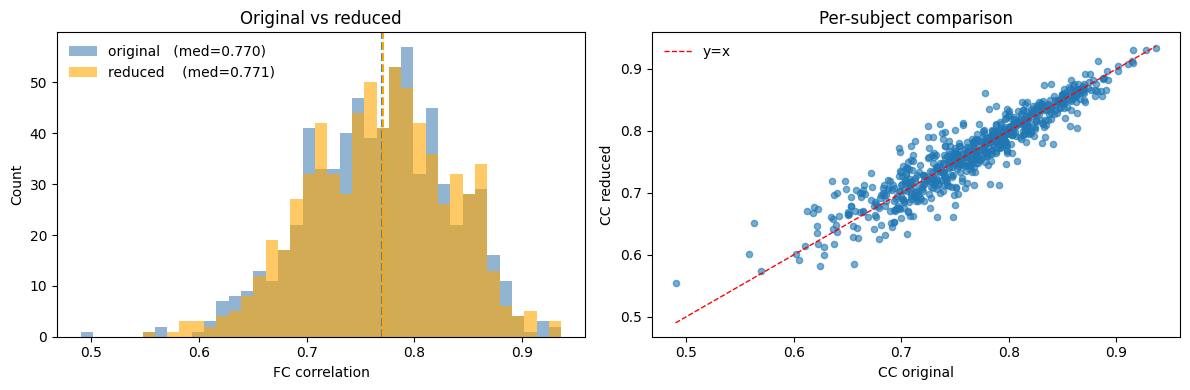

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# ── Panel 0: overlapping histograms ──────────────────────────
bins = np.linspace(
    min(np.min(ccs_orig), np.min(ccs_reduced)),
    max(np.max(ccs_orig), np.max(ccs_reduced)),
    40
)

ax[0].hist(ccs_orig,    bins=bins, alpha=0.6, color='steelblue',
           label=f'original   (med={np.median(ccs_orig):.3f})')
ax[0].hist(ccs_reduced, bins=bins, alpha=0.6, color='orange',
           label=f'reduced    (med={np.median(ccs_reduced):.3f})')
ax[0].axvline(np.median(ccs_orig),    color='steelblue', linestyle='--', linewidth=1.5)
ax[0].axvline(np.median(ccs_reduced), color='orange',    linestyle='--', linewidth=1.5)
ax[0].set_xlabel("FC correlation"); ax[0].set_ylabel("Count")
ax[0].set_title("Original vs reduced")
ax[0].legend(frameon=False)

# ── Panel 1: scatter original vs reduced (one dot per subject) ─
ax[1].scatter(ccs_orig, ccs_reduced, alpha=0.6, s=20)
lims = [min(np.min(ccs_orig), np.min(ccs_reduced)),
        max(np.max(ccs_orig), np.max(ccs_reduced))]
ax[1].plot(lims, lims, 'r--', linewidth=1, label='y=x')
ax[1].set_xlabel("CC original"); ax[1].set_ylabel("CC reduced")
ax[1].set_title("Per-subject comparison")
ax[1].legend(frameon=False)

# ── Stats ─────────────────────────────────────────────────────
t_stat, p_val = stats.wilcoxon(ccs_orig, ccs_reduced)
diff = np.array(ccs_reduced) - np.array(ccs_orig)
print(f"Original  — mean: {np.mean(ccs_orig):.3f}  median: {np.median(ccs_orig):.3f}  std: {np.std(ccs_orig):.3f}")
print(f"Reduced   — mean: {np.mean(ccs_reduced):.3f}  median: {np.median(ccs_reduced):.3f}  std: {np.std(ccs_reduced):.3f}")
print(f"Difference (reduced - original) — mean: {diff.mean():.3f}  std: {diff.std():.3f}")
print(f"Wilcoxon signed-rank test: stat={t_stat:.3f}  p={p_val:.4f}")

plt.tight_layout()
plt.show()

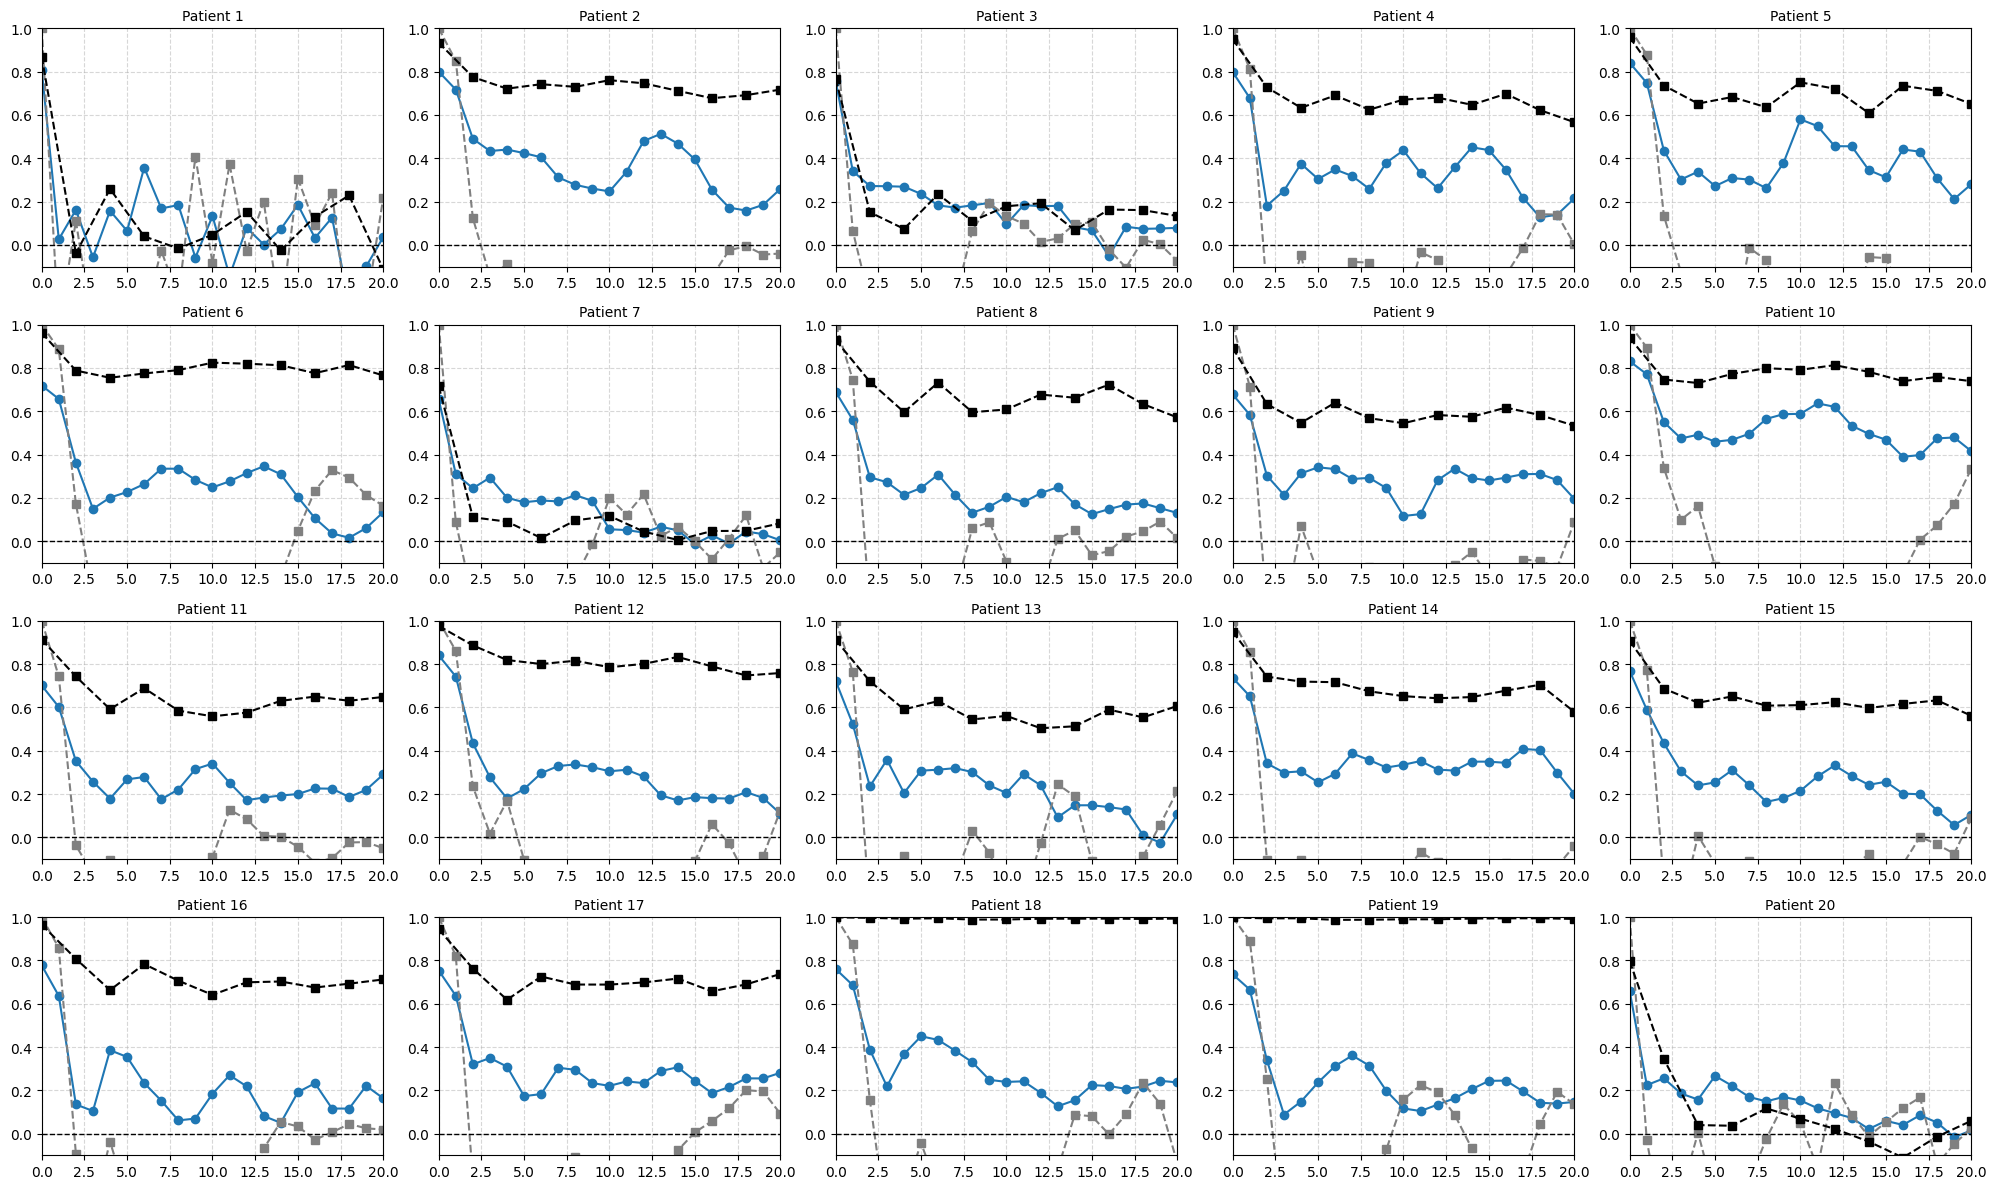

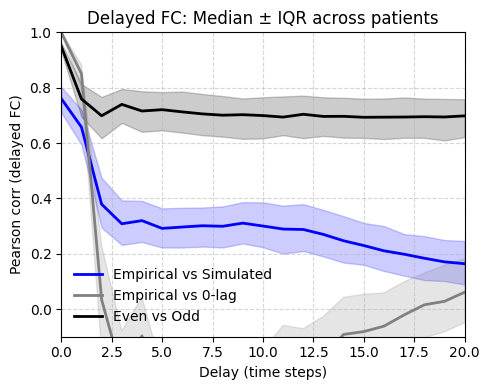

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def compute_delayed_fc(data, delay):
    """Return delayed FC matrix for a given delay (data shape: regions x time)."""
    if delay < 0:
        raise ValueError("delay must be >= 0")
    if delay == 0:
        return np.nan_to_num(np.corrcoef(data))
    if data.shape[1] <= delay:
        raise ValueError("delay must be smaller than the number of time points")

    lead = data[:, :-delay]
    lag = data[:, delay:]
    corr = np.corrcoef(lead, lag)
    delayed_block = corr[data.shape[0]:, :data.shape[0]]
    return np.nan_to_num(delayed_block)


times_to_skip = 10
max_delay = 20
num_examples = 20  # first 20 patients

all_corr = []
all_corr_ref = []
all_corr_ref_top = []

# --- Collect all trajectories ---
for patinent in range(len(Y_coll)):

    empirical_data_trimmed = Y_coll[patinent][:, times_to_skip:].T
    sim_data_trimmed = Y_coll_sim[patinent][times_to_skip:, :]

    empirical_data_trimmed_even = empirical_data_trimmed[:, ::2]
    empirical_data_trimmed_odd = empirical_data_trimmed[:, 1::2]

    correlations_vs_delay = []
    corr_val_ref_vs_delay = []
    corr_val_ref_top_vs_delay = []
    valid_delays = []

    fc_emp_0 = compute_delayed_fc(empirical_data_trimmed, 0)

    for delay in range(0, max_delay + 1):
        if delay > 0 and (
            empirical_data_trimmed.shape[1] <= delay or
            sim_data_trimmed.shape[1] <= delay
        ):
            break

        fc_emp = compute_delayed_fc(empirical_data_trimmed, delay)
        fc_sim = compute_delayed_fc(sim_data_trimmed, delay)

        correlations_vs_delay.append(np.corrcoef(fc_emp.flatten(), fc_sim.flatten())[0, 1])
        corr_val_ref_vs_delay.append(np.corrcoef(fc_emp.flatten(), fc_emp_0.flatten())[0, 1])
        corr_val_ref_top_vs_delay.append(
            np.corrcoef(
                compute_delayed_fc(empirical_data_trimmed_even, delay).flatten(),
                compute_delayed_fc(empirical_data_trimmed_odd, delay).flatten()
            )[0, 1]
        )
        valid_delays.append(delay)

    all_corr.append(correlations_vs_delay)
    all_corr_ref.append(corr_val_ref_vs_delay)
    all_corr_ref_top.append(corr_val_ref_top_vs_delay)

# -----------------------------
# 1️⃣ Plot 20 single panels
# -----------------------------
plt.figure(figsize=(20, 12))
for i, pat in enumerate(range(num_examples)):
    ax = plt.subplot(4, 5, i + 1)
    ax.plot(valid_delays, all_corr[pat], marker='o')
    ax.plot(valid_delays, all_corr_ref[pat], marker='s', linestyle='--', color='gray')
    ax.plot(np.array(valid_delays)*2, all_corr_ref_top[pat], marker='s', linestyle='--', color='k')

    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_ylim(-0.1, 1)
    ax.set_xlim(0, max_delay)
    ax.set_title(f'Patient {pat+1}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i < 15: ax.set_xlabel('')
    if i % 5 != 0: ax.set_ylabel('')

plt.tight_layout()
plt.show()

# -----------------------------
# 2️⃣ Plot chunk average (median + IQR)
# -----------------------------
def plot_with_stats(trajectories, color, label):
    arr = np.stack(trajectories)
    median = np.median(arr, axis=0)
    p25 = np.percentile(arr, 25, axis=0)
    p75 = np.percentile(arr, 75, axis=0)
    plt.plot(median, color=color, label=label, linewidth=2)
    plt.fill_between(np.arange(len(median)), p25, p75, color=color, alpha=0.2)

plt.figure(figsize=(5, 4))
plot_with_stats(all_corr, 'blue', 'Empirical vs Simulated')
plot_with_stats(all_corr_ref, 'gray', 'Empirical vs 0-lag')
plot_with_stats(all_corr_ref_top, 'k', 'Even vs Odd')

plt.xlabel('Delay (time steps)')
plt.ylabel('Pearson corr (delayed FC)')
plt.title('Delayed FC: Median ± IQR across patients')
plt.ylim(-0.1, 1)
plt.xlim(0, max_delay)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()


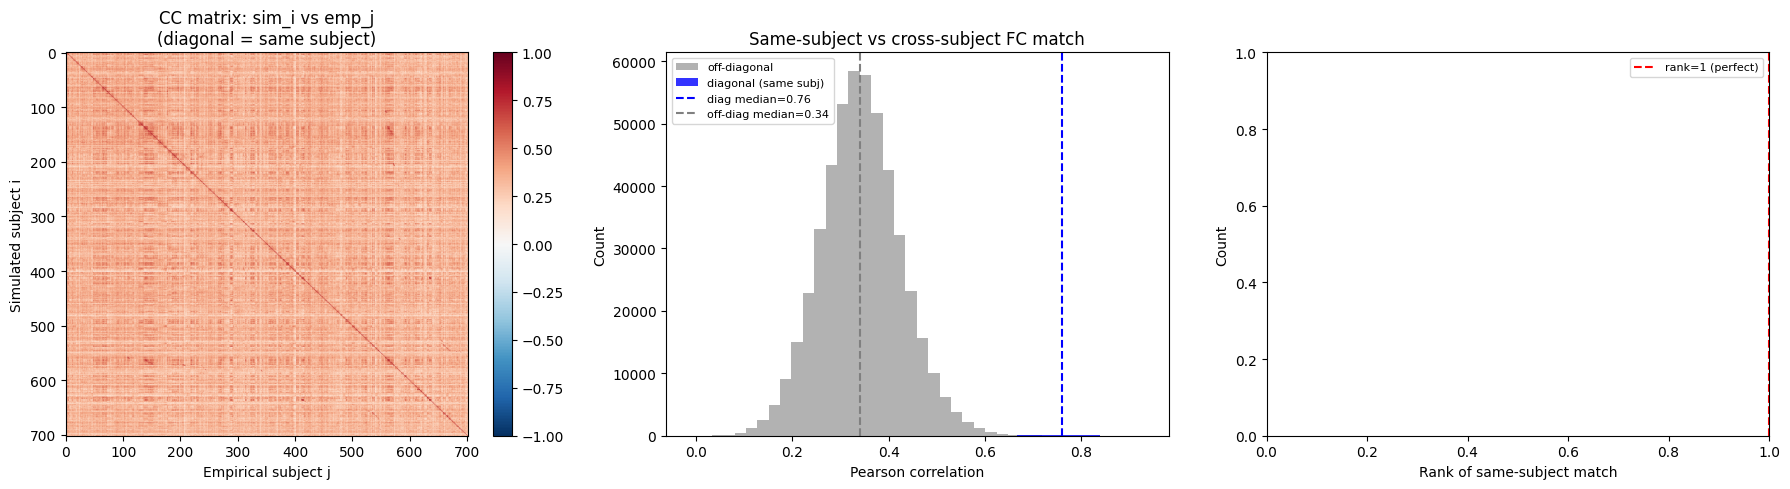


Same-subject FC corr  — median: 0.760  mean: 0.757
Cross-subject FC corr — median: 0.341  mean: 0.343


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def compute_delayed_fc(data, delay):
    if delay == 0:
        return np.nan_to_num(np.corrcoef(data))
    lead = data[:, :-delay]
    lag  = data[:, delay:]
    corr = np.corrcoef(lead, lag)
    return np.nan_to_num(corr[data.shape[0]:, :data.shape[0]])


times_to_skip = 10
max_delay     = 40
num_examples  = 20
P             = len(Y_coll)

all_corr          = []
all_corr_ref      = []
all_corr_ref_top  = []

# ============================================================
# Cross-subject FC matrix at delay=0
# cc_matrix[i, j] = corr(FC_sim_i, FC_emp_j)
# Diagonal = same-subject match (should be maximum per row)
# ============================================================
cc_matrix = np.zeros((P, P))

fc_emp_flat_all = []   # store all empirical FC for cross-subject comparison
fc_sim_flat_all = []   # store all simulated FC

for patient in range(P):
    emp = Y_coll[patient][:, times_to_skip:].T         # [N, T]
    sim = Y_coll_sim[patient][times_to_skip:, :]     # [N, T]
    fc_emp_flat_all.append(compute_delayed_fc(emp, 0).flatten())
    fc_sim_flat_all.append(compute_delayed_fc(sim, 0).flatten())

# Fill cross-subject matrix
for i in range(P):
    for j in range(P):
        cc_matrix[i, j] = np.corrcoef(
            fc_sim_flat_all[i],
            fc_emp_flat_all[j]
        )[0, 1]

# ============================================================
# Plot 3 — cross-subject FC correlation matrix  (delay=0)
# Diagonal should be the maximum of each row
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

im = ax[0].imshow(cc_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax[0].set_title("CC matrix: sim_i vs emp_j\n(diagonal = same subject)")
ax[0].set_xlabel("Empirical subject j")
ax[0].set_ylabel("Simulated subject i")
plt.colorbar(im, ax=ax[0])

# Diagonal vs off-diagonal distributions
diag_vals    = np.diag(cc_matrix)
offdiag_vals = cc_matrix[~np.eye(P, dtype=bool)]
ax[1].hist(offdiag_vals, bins=40, alpha=0.6, color='gray',  label='off-diagonal')
ax[1].hist(diag_vals,    bins=20, alpha=0.8, color='blue',  label='diagonal (same subj)')
ax[1].axvline(np.median(diag_vals),    color='blue', linestyle='--',
              label=f'diag median={np.median(diag_vals):.2f}')
ax[1].axvline(np.median(offdiag_vals), color='gray', linestyle='--',
              label=f'off-diag median={np.median(offdiag_vals):.2f}')
ax[1].set_xlabel("Pearson correlation"); ax[1].set_ylabel("Count")
ax[1].set_title("Same-subject vs cross-subject FC match")
ax[1].legend(fontsize=8)


ax[2].axvline(1, color='red', linestyle='--', label='rank=1 (perfect)')
ax[2].set_xlabel("Rank of same-subject match")
ax[2].set_ylabel("Count")

ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nSame-subject FC corr  — median: {np.median(diag_vals):.3f}  "
      f"mean: {np.mean(diag_vals):.3f}")
print(f"Cross-subject FC corr — median: {np.median(offdiag_vals):.3f}  "
      f"mean: {np.mean(offdiag_vals):.3f}")


In [31]:
# sklearn already installed in mc_env

Seed 0
Seed 1
Seed 2


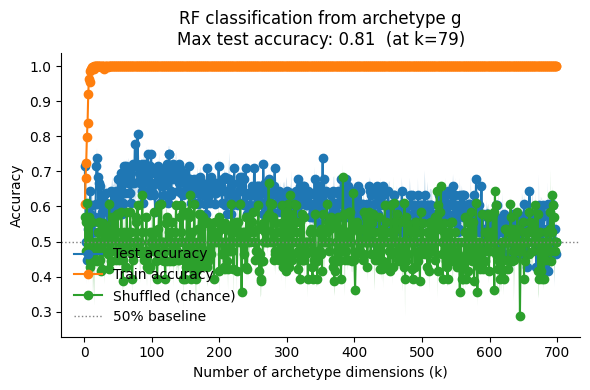

In [32]:
# ============================================================
# Step 2 – Classification with PyTorch MLP (no scikit-learn)
# ============================================================
import torch
import torch.nn as nn

n_pc = G_scores.shape[1]

all_colors_arr    = np.array([state_ID_numeric[pid] for pid in all_ids])
data_cleaned      = np.copy(G_scores)
filtered_labels   = np.copy(all_colors_arr)
patient_ids_clean = np.copy(patient_ID_resting)

def _train_test_split(arr, test_size=0.15, seed=None):
    rng = np.random.default_rng(seed)
    arr = np.asarray(arr)
    idx = rng.permutation(len(arr))
    n_test = max(1, int(len(arr) * test_size))
    return arr[idx[n_test:]], arr[idx[:n_test]]

def balance_classes(X, y, class0=0, class1=target_class, seed=None):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == class0)[0]
    idx1 = np.where(y == class1)[0]
    n    = min(len(idx0), len(idx1))
    rng.shuffle(idx0); rng.shuffle(idx1)
    sel  = np.concatenate([idx0[:n], idx1[:n]])
    return X[sel], y[sel]

def _accuracy(y_true, y_pred):
    return (np.asarray(y_true) == np.asarray(y_pred)).mean()

class _MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),     nn.ReLU(),
            nn.Linear(16, 2),
        )
    def forward(self, x):
        return self.net(x)

def _fit_predict(X_tr, y_tr, X_te, n_epochs=300, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    classes   = np.unique(y_tr)
    to_idx    = {c: i for i, c in enumerate(classes)}
    from_idx  = {i: c for c, i in to_idx.items()}
    y_t = torch.tensor([to_idx[c] for c in y_tr], dtype=torch.long)
    Xt  = torch.tensor(X_tr, dtype=torch.float32)
    Xe  = torch.tensor(X_te, dtype=torch.float32)
    model = _MLP(X_tr.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for _ in range(n_epochs):
        opt.zero_grad(); loss_fn(model(Xt), y_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        tr_pred = np.array([from_idx[i] for i in model(Xt).argmax(1).numpy()])
        te_pred = np.array([from_idx[i] for i in model(Xe).argmax(1).numpy()])
    return tr_pred, te_pred

# --- Repeated MLP across random seeds ---
test_accuracies_all  = []
train_accuracies_all = []
shuffled_test_all    = []

ks = range(1, M)

for random_state in range(3):
    print(f"Seed {random_state}")
    rng_seed = np.random.randint(1000)
    test_accs, train_accs, shuffled_accs = [], [], []

    for k in ks:
        unique_patients                = np.unique(patient_ids_clean)
        train_patients, test_patients  = _train_test_split(
            unique_patients, test_size=0.15, seed=rng_seed)

        train_mask = np.isin(patient_ids_clean, train_patients)
        test_mask  = np.isin(patient_ids_clean, test_patients)

        X_train = data_cleaned[train_mask, :k]
        X_test  = data_cleaned[test_mask,  :k]
        y_train = filtered_labels[train_mask]
        y_test  = filtered_labels[test_mask]

        X_train, y_train = balance_classes(X_train, y_train, seed=rng_seed)
        X_test,  y_test  = balance_classes(X_test,  y_test,  seed=rng_seed)

        if len(X_train) == 0 or len(X_test) == 0:
            test_accs.append(np.nan); train_accs.append(np.nan)
            shuffled_accs.append(np.nan); continue

        tr_pred, te_pred = _fit_predict(X_train, y_train, X_test, seed=rng_seed)

        train_accs.append(_accuracy(y_train, tr_pred))
        test_accs.append(_accuracy(y_test,   te_pred))
        shuffled_accs.append(_accuracy(np.random.permutation(y_test), te_pred))

    test_accuracies_all.append(test_accs)
    train_accuracies_all.append(train_accs)
    shuffled_test_all.append(shuffled_accs)

# ============================================================
# Step 3 – Aggregate & Plot
# ============================================================

avg_test   = np.median(test_accuracies_all,  axis=0)
avg_train  = np.median(train_accuracies_all, axis=0)
avg_shuff  = np.median(shuffled_test_all,    axis=0)

p20_test,  p80_test  = np.percentile(test_accuracies_all,  [20, 80], axis=0)
p20_train, p80_train = np.percentile(train_accuracies_all, [20, 80], axis=0)
p20_shuff, p80_shuff = np.percentile(shuffled_test_all,    [20, 80], axis=0)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ks, avg_test,  '-o', label='Test accuracy')
ax.fill_between(ks, p20_test,  p80_test,  alpha=0.2)

ax.plot(ks, avg_train, '-o', label='Train accuracy')
ax.fill_between(ks, p20_train, p80_train, alpha=0.2)

ax.plot(ks, avg_shuff, '-o', label='Shuffled (chance)')
ax.fill_between(ks, p20_shuff, p80_shuff, alpha=0.2)

ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='50% baseline')

ax.set_xlabel('Number of archetype dimensions (k)')
ax.set_ylabel('Accuracy')
ax.set_title(
    f'RF classification from archetype g\n'
    f'Max test accuracy: {np.max(avg_test):.2f}  '
    f'(at k={np.argmax(avg_test)+1})'
)

legend = ax.legend()
legend.get_frame().set_facecolor('none')
legend.get_frame().set_edgecolor('none')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_lda.png', dpi=150)
plt.savefig('fig_lda.pdf')
plt.show()


Seed 0
Seed 1
Seed 2


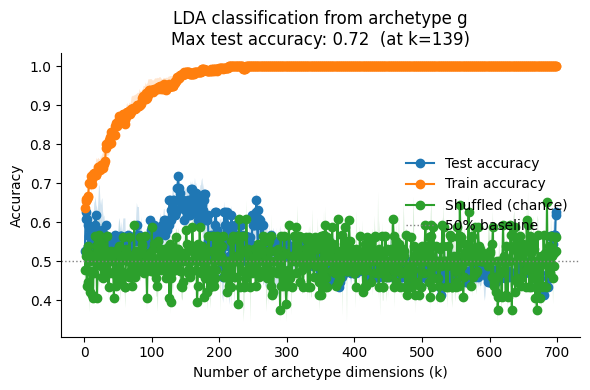

In [33]:
# ============================================================
# Step 2 – Classification with LDA (numpy, no scikit-learn)
# ============================================================

n_pc = G_scores.shape[1]

all_colors_arr    = np.array([state_ID_numeric[pid] for pid in all_ids])
data_cleaned      = np.copy(G_scores)
filtered_labels   = np.copy(all_colors_arr)
patient_ids_clean = np.copy(patient_ID_resting)

def balance_classes(X, y, class0=0, class1=target_class, seed=None):
    rng  = np.random.default_rng(seed)
    idx0 = np.where(y == class0)[0]
    idx1 = np.where(y == class1)[0]
    n    = min(len(idx0), len(idx1))
    rng.shuffle(idx0); rng.shuffle(idx1)
    sel  = np.concatenate([idx0[:n], idx1[:n]])
    return X[sel], y[sel]

class _LDA:
    """Binary Fisher LDA — sklearn-compatible interface (numpy only)."""
    def __init__(self, n_components=1, solver='svd'):
        pass
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        assert len(self.classes_) == 2, "_LDA only supports binary classification"
        c0, c1 = self.classes_[0], self.classes_[1]
        X0, X1 = X[y == c0], X[y == c1]
        mu0, mu1 = X0.mean(0), X1.mean(0)
        Sw = (X0 - mu0).T @ (X0 - mu0) + (X1 - mu1).T @ (X1 - mu1)
        Sw += 1e-6 * np.eye(Sw.shape[0])
        w = np.linalg.solve(Sw, mu1 - mu0)
        w /= np.linalg.norm(w) + 1e-12
        thr = 0.5 * ((X0 @ w).mean() + (X1 @ w).mean())
        self.scalings_  = w.reshape(-1, 1)
        self.coef_      = w.reshape(1, -1)
        self.intercept_ = np.array([-thr])
        return self
    def transform(self, X):
        return X @ self.scalings_
    def predict(self, X):
        w   = self.scalings_.ravel()
        thr = -self.intercept_[0]
        return np.where(X @ w >= thr, self.classes_[1], self.classes_[0])

def _train_test_split(arr, test_size=0.15, seed=None):
    rng = np.random.default_rng(seed)
    arr = np.asarray(arr)
    idx = rng.permutation(len(arr))
    n_test = max(1, int(len(arr) * test_size))
    return arr[idx[n_test:]], arr[idx[:n_test]]

def _accuracy(y_true, y_pred):
    return (np.asarray(y_true) == np.asarray(y_pred)).mean()

test_accuracies_all  = []
train_accuracies_all = []
shuffled_test_all    = []

ks = range(1, M)

for random_state in range(3):
    print(f"Seed {random_state}")
    rng_seed = np.random.randint(1000)
    test_accs, train_accs, shuffled_accs = [], [], []

    for k in ks:
        unique_patients               = np.unique(patient_ids_clean)
        train_patients, test_patients = _train_test_split(
            unique_patients, test_size=0.15, seed=rng_seed)

        train_mask = np.isin(patient_ids_clean, train_patients)
        test_mask  = np.isin(patient_ids_clean, test_patients)

        X_train = data_cleaned[train_mask, :k]
        X_test  = data_cleaned[test_mask,  :k]
        y_train = filtered_labels[train_mask]
        y_test  = filtered_labels[test_mask]

        X_train, y_train = balance_classes(X_train, y_train, seed=rng_seed)
        X_test,  y_test  = balance_classes(X_test,  y_test,  seed=rng_seed)

        if len(X_train) == 0 or len(X_test) == 0:
            test_accs.append(np.nan); train_accs.append(np.nan)
            shuffled_accs.append(np.nan); continue

        lda = _LDA().fit(X_train, y_train)

        train_accs.append(_accuracy(y_train, lda.predict(X_train)))
        test_accs.append( _accuracy(y_test,  lda.predict(X_test)))
        shuffled_accs.append(
            _accuracy(np.random.permutation(y_test), lda.predict(X_test)))

    test_accuracies_all.append(test_accs)
    train_accuracies_all.append(train_accs)
    shuffled_test_all.append(shuffled_accs)

# ============================================================
# Step 3 – Aggregate & Plot
# ============================================================

avg_test   = np.median(test_accuracies_all,  axis=0)
avg_train  = np.median(train_accuracies_all, axis=0)
avg_shuff  = np.median(shuffled_test_all,    axis=0)

p20_test,  p80_test  = np.percentile(test_accuracies_all,  [20, 80], axis=0)
p20_train, p80_train = np.percentile(train_accuracies_all, [20, 80], axis=0)
p20_shuff, p80_shuff = np.percentile(shuffled_test_all,    [20, 80], axis=0)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ks, avg_test,  '-o', label='Test accuracy')
ax.fill_between(ks, p20_test,  p80_test,  alpha=0.2)

ax.plot(ks, avg_train, '-o', label='Train accuracy')
ax.fill_between(ks, p20_train, p80_train, alpha=0.2)

ax.plot(ks, avg_shuff, '-o', label='Shuffled (chance)')
ax.fill_between(ks, p20_shuff, p80_shuff, alpha=0.2)

ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='50% baseline')
ax.set_xlabel('Number of archetype dimensions (k)')
ax.set_ylabel('Accuracy')
ax.set_title(
    f'LDA classification from archetype g\n'
    f'Max test accuracy: {np.max(avg_test):.2f}  '
    f'(at k={np.argmax(avg_test)+1})'
)
legend = ax.legend()
legend.get_frame().set_facecolor('none')
legend.get_frame().set_edgecolor('none')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig_lda.png', dpi=150)
plt.savefig('fig_lda.pdf')
plt.show()


Fold  1 | MAE: 0.4096 | R2: -0.2400
Fold  2 | MAE: 0.3760 | R2: -0.2887
Fold  3 | MAE: 0.3943 | R2: -0.4671
Fold  4 | MAE: 0.4430 | R2: -0.2087
Fold  5 | MAE: 0.3936 | R2: -0.2973
Fold  6 | MAE: 0.4373 | R2: -0.3313
Fold  7 | MAE: 0.3739 | R2: -0.1677
Fold  8 | MAE: 0.2703 | R2: -0.0018
Fold  9 | MAE: 0.2904 | R2: -0.4320
Fold 10 | MAE: 0.3573 | R2: -0.2609

Average over 10 folds
 Class  True target    Mean pred +/- std        MAE +/- std
--------------------------------------------------------------
     0        0.000      0.204 +/- 0.046     0.214 +/- 0.040
     1        0.250        nan +/- nan         nan +/- nan
     2        0.500        nan +/- nan         nan +/- nan
     3        0.750        nan +/- nan         nan +/- nan
     4        1.000      0.185 +/- 0.051     0.815 +/- 0.051

Overall test MAE: 0.3746 +/- 0.0537
Overall test R2:  -0.2695 +/- 0.1253


C:\Users\user\AppData\Local\Temp\ipykernel_22652\469307487.py:95: RuntimeWarning: Mean of empty slice
  mean_preds = np.nanmean(fold_mean_preds, axis=0)
c:\Users\user\Desktop\2026.AD_MotionCorrection\bids_env\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\user\AppData\Local\Temp\ipykernel_22652\469307487.py:97: RuntimeWarning: Mean of empty slice
  mean_mae   = np.nanmean(fold_mae,         axis=0)


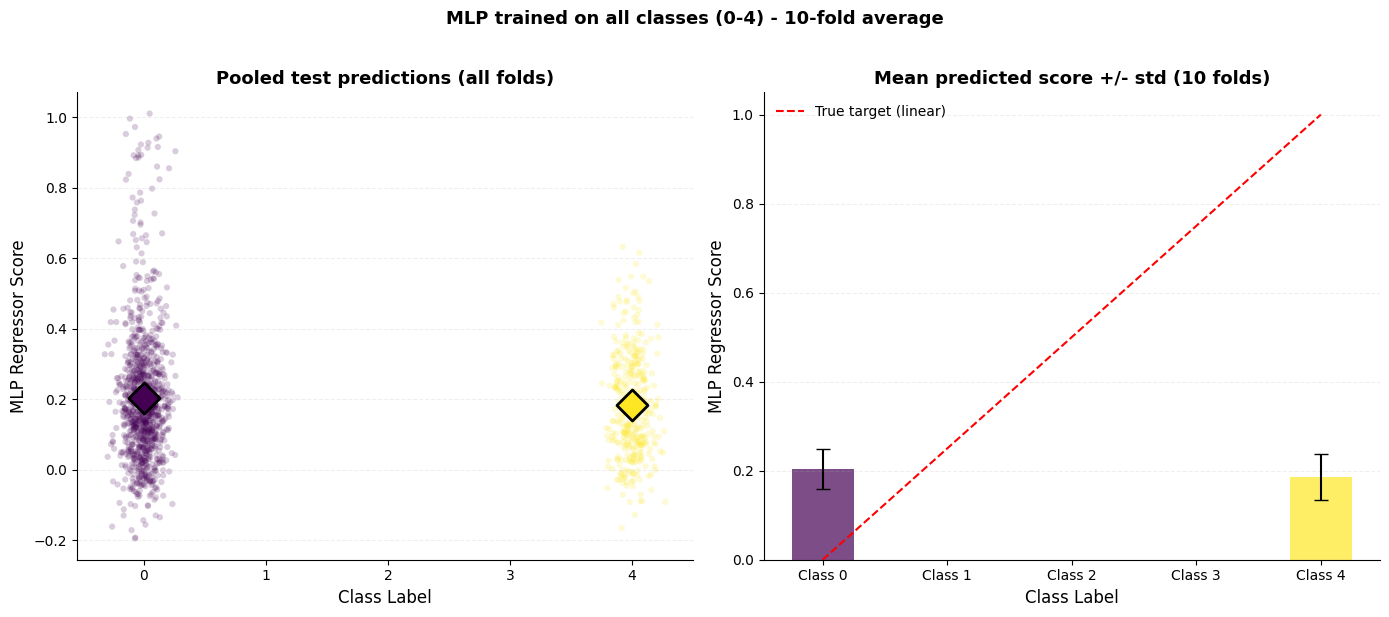

In [34]:
import torch
import torch.nn as nn

N_FOLDS   = 10
n_classes = 5

data_cleaned = np.copy(G_scores)

def _train_test_split(arr, test_size=0.2, seed=None):
    rng = np.random.default_rng(seed)
    arr = np.asarray(arr)
    idx = rng.permutation(len(arr))
    n_test = max(1, int(len(arr) * test_size))
    return arr[idx[n_test:]], arr[idx[:n_test]]

def _r2(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / (ss_tot + 1e-12)

def _mae(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()

class _MLPReg(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),     nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def _fit_reg(X_tr, y_tr, X_te, n_epochs=400, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32)
    Xe = torch.tensor(X_te, dtype=torch.float32)
    model = _MLPReg(X_tr.shape[1])
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for _ in range(n_epochs):
        opt.zero_grad(); loss_fn(model(Xt), yt).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return model(Xe).numpy()

# Accumulators
fold_mean_preds  = np.zeros((N_FOLDS, n_classes))
fold_mae         = np.zeros((N_FOLDS, n_classes))
fold_overall_mae = np.zeros(N_FOLDS)
fold_overall_r2  = np.zeros(N_FOLDS)

all_test_preds  = []
all_test_labels = []

for fold in range(N_FOLDS):
    unique_patients = np.unique(patient_ids_clean)
    train_p, test_p = _train_test_split(unique_patients, test_size=0.2, seed=fold)

    train_mask = np.isin(patient_ids_clean, train_p)
    test_mask  = np.isin(patient_ids_clean, test_p)

    X_train_full = data_cleaned[train_mask]
    y_train_full = filtered_labels[train_mask]
    X_test_full  = data_cleaned[test_mask]
    y_test_full  = filtered_labels[test_mask]

    y_train_cont = y_train_full / 4.0
    y_test_cont  = y_test_full  / 4.0

    reg_test = _fit_reg(X_train_full, y_train_cont, X_test_full, seed=fold)

    for cls in range(n_classes):
        mask = (y_test_full == cls)
        if not np.any(mask):
            fold_mean_preds[fold, cls] = np.nan
            fold_mae[fold, cls]        = np.nan
        else:
            preds = reg_test[mask]
            fold_mean_preds[fold, cls] = np.mean(preds)
            fold_mae[fold, cls]        = np.mean(np.abs(preds - cls / 4.0))

    fold_overall_mae[fold] = _mae(y_test_cont, reg_test)
    fold_overall_r2[fold]  = _r2(y_test_cont,  reg_test)

    all_test_preds.append(reg_test)
    all_test_labels.append(y_test_full)

    print(f"Fold {fold+1:2d} | MAE: {fold_overall_mae[fold]:.4f} | R2: {fold_overall_r2[fold]:.4f}")

# Summary
mean_preds = np.nanmean(fold_mean_preds, axis=0)
std_preds  = np.nanstd(fold_mean_preds,  axis=0)
mean_mae   = np.nanmean(fold_mae,         axis=0)
std_mae    = np.nanstd(fold_mae,          axis=0)

print(f"\n{'':=<62}")
print(f"Average over {N_FOLDS} folds")
print(f"{'':=<62}")
print(f"{'Class':>6} {'True target':>12} {'Mean pred +/- std':>20} {'MAE +/- std':>18}")
print("-" * 62)
for cls in range(n_classes):
    target = cls / 4.0
    print(f"{cls:>6} {target:>12.3f} "
          f"{mean_preds[cls]:>10.3f} +/- {std_preds[cls]:<6.3f} "
          f"{mean_mae[cls]:>8.3f} +/- {std_mae[cls]:.3f}")

print(f"\nOverall test MAE: {fold_overall_mae.mean():.4f} +/- {fold_overall_mae.std():.4f}")
print(f"Overall test R2:  {fold_overall_r2.mean():.4f} +/- {fold_overall_r2.std():.4f}")

# Plot
all_preds_cat  = np.concatenate(all_test_preds)
all_labels_cat = np.concatenate(all_test_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0, 1, n_classes))

ax = axes[0]
for cls in range(n_classes):
    mask = (all_labels_cat == cls)
    if not np.any(mask): continue
    y_vals   = all_preds_cat[mask]
    x_jitter = np.random.normal(cls, 0.1, size=len(y_vals))
    ax.scatter(x_jitter, y_vals, color=colors[cls], alpha=0.2, s=20, edgecolors='none')
    ax.scatter(cls, np.mean(y_vals), color=colors[cls], s=250, marker='D',
               edgecolors='black', linewidth=2, zorder=5)
ax.set_title("Pooled test predictions (all folds)", fontweight='bold', fontsize=13)
ax.set_xlabel("Class Label", fontsize=12); ax.set_ylabel("MLP Regressor Score", fontsize=12)
ax.set_xticks(range(n_classes))
ax.grid(True, axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
x = np.arange(n_classes)
ax.bar(x, mean_preds, color=colors, alpha=0.7, width=0.5)
ax.errorbar(x, mean_preds, yerr=std_preds, fmt='none', color='black', capsize=5, linewidth=1.5)
ax.plot(x, [c / 4.0 for c in range(n_classes)], color='red', linewidth=1.5,
        linestyle='--', label="True target (linear)")
ax.set_title(f"Mean predicted score +/- std ({N_FOLDS} folds)", fontweight='bold', fontsize=13)
ax.set_xlabel("Class Label", fontsize=12); ax.set_ylabel("MLP Regressor Score", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels([f"Class {c}" for c in range(n_classes)])
ax.legend(loc='best', frameon=False)
ax.grid(True, axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle(f"MLP trained on all classes (0-4) - {N_FOLDS}-fold average",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [35]:
# %%
# ============================================================
# Therapeutic intervention — binary CC (0) vs AD (4)
#
#   ΔY     = α · X @ (W_cc_mean − W_self)   [T', N_sites]
#   Y_pert = Y + ΔY
#   W_new  = pinv(X) @ Y_pert
#   g_new  = (W_new.T.flatten() − W_mean) @ Vt_s[:M].T
#
# Goal: AD patients (class 4) shift toward CC (class 0)
#       as α increases.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
# _LDA defined in cell 33 (numpy implementation)
from scipy.stats import gaussian_kde

# ── indices for the two classes ────────────────────────────────────────────
ctrl_indices = [i for i, c in enumerate(state_ID_numeric) if c == 0]
ad_indices   = [i for i, c in enumerate(state_ID_numeric) if c == 4]

print(f"CC (class 0): {len(ctrl_indices)} subjects")
print(f"AD (class 4): {len(ad_indices)}   subjects")

# ── 1. W_cc_mean ───────────────────────────────────────────────────────────
W_cc_mean = np.mean(
    [fitted_weights_list[i] for i in ctrl_indices], axis=0
)   # [N_res, N_sites]
print(f"W_cc_mean shape: {W_cc_mean.shape}")

# CC mean FC (diagnostic)
fc_ctrl_mean = np.mean(
    [FC_collected[i] for i in ctrl_indices], axis=0
)

# ── 2. Reference _LDA(binary, 1 component) ────────────────────────────────
keep_lda   = np.array([i for i, c in enumerate(state_ID_numeric) if c in (0, 4)])
y_lda      = np.array([0 if state_ID_numeric[i] == 0 else 1 for i in keep_lda])
X_lda      = G_scores[keep_lda]           # [P_sub, M]

lda_ref = _LDA(n_components=1)
lda_ref.fit(X_lda, y_lda)

# Project and orient: class-0 on the left (negative side)
Z_ref = lda_ref.transform(X_lda).ravel()   # [P_sub]
if Z_ref[y_lda == 0].mean() > Z_ref[y_lda == 1].mean():
    # flip the LDA direction so CC < AD on the axis
    lda_ref.scalings_ *= -1
    lda_ref.coef_     *= -1
    lda_ref.intercept_ *= -1

Z_ref = lda_ref.transform(X_lda).ravel()
print(f"\nOriginal LDA score — CC mean: {Z_ref[y_lda==0].mean():.3f}  "
      f"AD mean: {Z_ref[y_lda==1].mean():.3f}")


CC (class 0): 557 subjects
AD (class 4): 145   subjects
W_cc_mean shape: (2000, 121)

Original LDA score — CC mean: -0.483  AD mean: 1.857


In [36]:
# %%
# ============================================================
# Dose sweep — intervention only on AD patients
#
# For AD: Jout_interp = (1-α)·W_self.T + α·W_cc_mean.T
# For CC: Jout unchanged
#
# Then run train_test normally (no perturbation flag needed).
# ============================================================

alpha_values = [0.0,  0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

results = {a: dict(g_new=[], fc_corr_ctrl=[],
                   z_lda=None, y_pred=None)
           for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   Jout = (1-α)·W_self + α·W_cc_mean  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Refit W_self ────────────────────────────────────────────────
        W_self = fitted_weights_list[patient]              # [N_res, N_sites]
        W_new  = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]

        # ── d. Interpolate Jout for AD, leave CC unchanged ─────────────────
        if is_ad:
            W_interp = (1 - alpha) * W_new + alpha * W_cc_mean  # [N_res, N_sites]
        else:
            W_interp = W_new

        network_reservoire.Jout = np.copy(W_interp.T)     # [N_sites, N_res]

        # ── e. Autonomous run ──────────────────────────────────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
        )

        # ── f. g_new via archetype projection of W_interp ──────────────────
        w_centered = W_interp.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results[alpha]['g_new']        = np.array(g_list)
    results[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results[alpha]['z_lda']  = z_new
    results[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")


────────────────────────────────────────────────────────────
  α = 0.00   Jout = (1-α)·W_self + α·W_cc_mean  [AD only]
────────────────────────────────────────────────────────────


  0%|          | 0/702 [00:00<?, ?it/s]

(139, 2000) (139, 121)


c:\Users\user\Desktop\2026.AD_MotionCorrection\bids_env\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\user\Desktop\2026.AD_MotionCorrection\bids_env\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 1/702 [00:00<02:18,  5.06it/s]

(139, 2000) (139, 121)


...

(139, 2000) (139, 121)
(139, 2000) (139, 121)


100%|█████████▉| 701/702 [01:38<00:00,  7.16it/s]

(139, 2000) (139, 121)
(139, 2000) (139, 121)


100%|██████████| 702/702 [01:38<00:00,  7.13it/s]

  CC  (n=557)  frac→CC=1.000  LDA mean=-0.918
  AD  (n=145)  frac→CC=1.000  LDA mean=-0.483


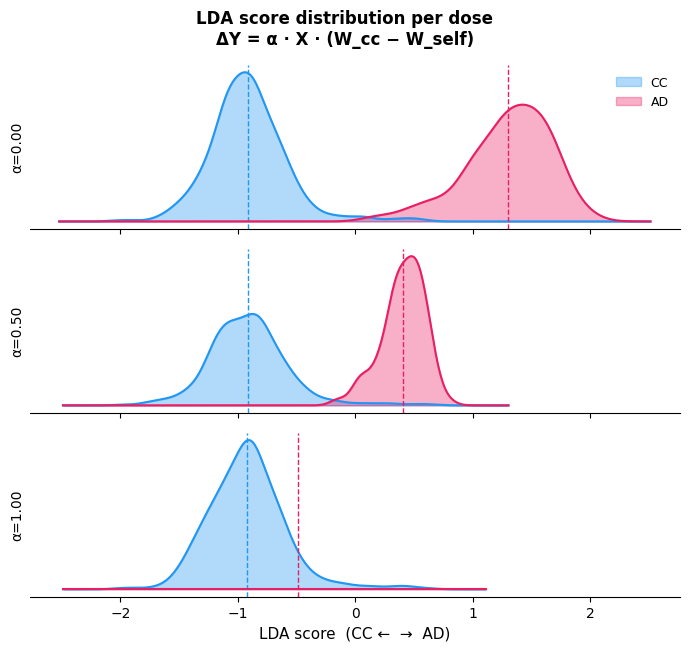

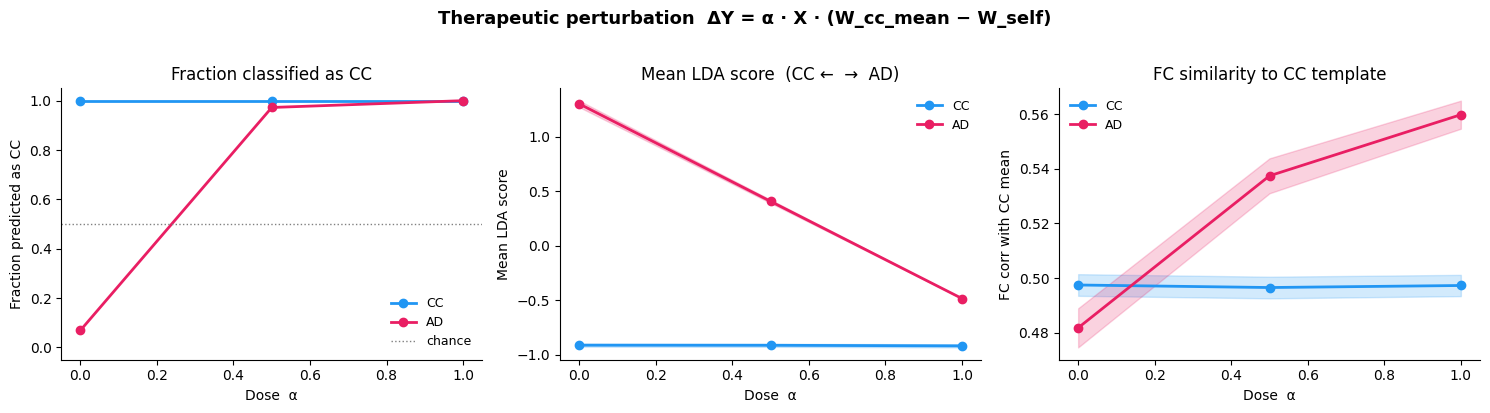


══════════════════════════════════════════════════════════
  SUMMARY  —  binary CC vs AD
══════════════════════════════════════════════════════════
      α     CC→CC     AD→CC    LDA(CC)    LDA(AD)   FC-corr(AD)
   0.00     1.000     0.069     -0.912      1.303         0.482
   0.50     1.000     0.972     -0.913      0.408         0.537
   1.00     1.000     1.000     -0.918     -0.483         0.560


In [37]:


# ── 5. Plots ───────────────────────────────────────────────────────────────
col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (1-D KDE ridgeline) ───────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

for ax, alpha in zip(axes, alpha_values):
    z     = results[alpha]['z_lda']
    x_min = z.min() - 0.5
    x_max = z.max() + 0.5
    xs    = np.linspace(x_min, x_max, 400)

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\nΔY = α · X · (W_cc − W_self)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('therapeutic_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction of AD predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose  (want AD to decrease toward CC)
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean vs dose
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Therapeutic perturbation  ΔY = α · X · (W_cc_mean − W_self)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('therapeutic_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 6. Numerical summary ───────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  binary CC vs AD")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [38]:
# %%
# ============================================================
# Dose sweep — intervention only on AD patients
#
# For AD: Jout_interp = (1-α)·W_self.T + α·W_cc_mean.T
# For CC: Jout unchanged
#
# Then run train_test normally (no perturbation flag needed).
# ============================================================

alpha_values = [0.0,  0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

results = {a: dict(g_new=[], fc_corr_ctrl=[],
                   z_lda=None, y_pred=None)
           for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   Jout = (1-α)·W_self + α·W_cc_mean  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Refit W_self ────────────────────────────────────────────────
        W_self = fitted_weights_list[patient]              # [N_res, N_sites]
        W_new  = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]
        W_targ = fitted_weights_list[ctrl_indices[np.random.randint(len(ctrl_indices))]]

        # ── d. Interpolate Jout for AD, leave CC unchanged ─────────────────
        if is_ad:
            W_interp = (1 - alpha) * W_new + alpha * W_targ  # [N_res, N_sites]
        else:
            W_interp = W_new

        network_reservoire.Jout = np.copy(W_interp.T)     # [N_sites, N_res]

        # ── e. Autonomous run ──────────────────────────────────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
        )

        # ── f. g_new via archetype projection of W_interp ──────────────────
        w_centered = W_interp.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results[alpha]['g_new']        = np.array(g_list)
    results[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results[alpha]['z_lda']  = z_new
    results[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")


────────────────────────────────────────────────────────────
  α = 0.00   Jout = (1-α)·W_self + α·W_cc_mean  [AD only]
────────────────────────────────────────────────────────────


  0%|          | 1/702 [00:00<01:43,  6.78it/s]

(139, 2000) (139, 121)
(139, 2000) (139, 121)


  0%|          | 3/702 [00:00<01:39,  7.03it/s]

(139, 2000) (139, 121)
(139, 2000) (139, 121)


...

(139, 2000) (139, 121)
(139, 2000) (139, 121)


100%|█████████▉| 701/702 [01:51<00:00,  6.46it/s]

(139, 2000) (139, 121)
(139, 2000) (139, 121)


100%|██████████| 702/702 [01:51<00:00,  6.30it/s]

  CC  (n=557)  frac→CC=1.000  LDA mean=-0.908
  AD  (n=145)  frac→CC=1.000  LDA mean=-0.488


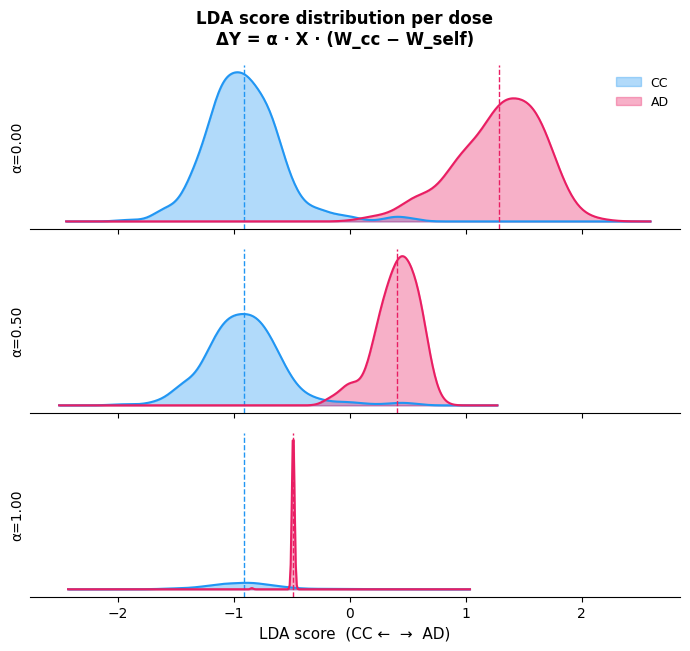

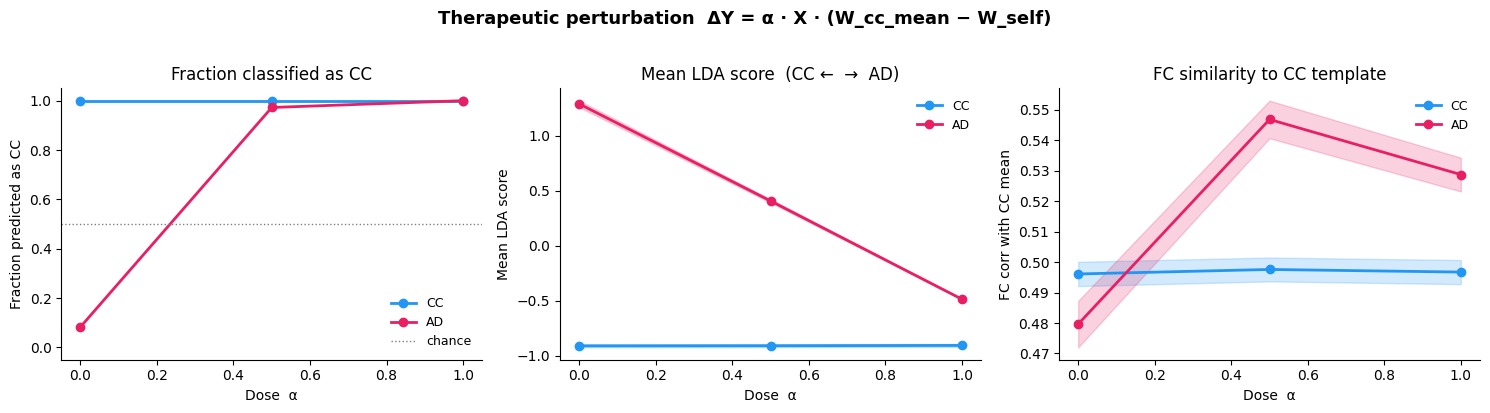


══════════════════════════════════════════════════════════
  SUMMARY  —  binary CC vs AD
══════════════════════════════════════════════════════════
      α     CC→CC     AD→CC    LDA(CC)    LDA(AD)   FC-corr(AD)
   0.00     1.000     0.083     -0.912      1.287         0.480
   0.50     1.000     0.972     -0.911      0.405         0.547
   1.00     1.000     1.000     -0.908     -0.488         0.529


In [39]:


# ── 5. Plots ───────────────────────────────────────────────────────────────
col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (1-D KDE ridgeline) ───────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

for ax, alpha in zip(axes, alpha_values):
    z     = results[alpha]['z_lda']
    x_min = z.min() - 0.5
    x_max = z.max() + 0.5
    xs    = np.linspace(x_min, x_max, 400)

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\nΔY = α · X · (W_cc − W_self)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('therapeutic_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction of AD predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose  (want AD to decrease toward CC)
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean vs dose
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Therapeutic perturbation  ΔY = α · X · (W_cc_mean − W_self)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('therapeutic_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 6. Numerical summary ───────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  binary CC vs AD")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [40]:
# %%
# ============================================================
# Dose sweep — intervention only on AD patients
#
# For AD: Jout_interp = (1-α)·W_self.T + α·W_cc_mean.T
# For CC: Jout unchanged
#
# Then run train_test normally (no perturbation flag needed).
# ============================================================

alpha_values = [0.0,  0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

results = {a: dict(g_new=[], fc_corr_ctrl=[],
                   z_lda=None, y_pred=None)
           for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   Jout = (1-α)·W_self + α·W_cc_mean  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Refit W_self ────────────────────────────────────────────────
        W_self = fitted_weights_list[patient]              # [N_res, N_sites]
        W_new  = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]
        W_targ = fitted_weights_list[ctrl_indices[np.random.randint(len(ctrl_indices))]]

        # ── d. Interpolate Jout for AD, leave CC unchanged ─────────────────
        if is_ad:
            apply_perturbation = True
            W_interp = (1 - alpha) * W_new + alpha * W_targ  # [N_res, N_sites]
        else:
            W_interp = W_new
            apply_perturbation = False

        network_reservoire.Jout = np.copy(W_new.T)  
        network_reservoire.J_targ = np.copy(W_targ.T)     # [N_sites, N_res]
        network_reservoire.alpha = alpha


        
        
        # ── e. Autonomous run with online perturbation ─────────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
            perturbation    = apply_perturbation,
        )

        # ── f. Re-estimate W from the simulated activity → g_new ──────────
        norm_mua_target = network_reservoire.data.T        # [N_sites, T']
        network_reservoire.T = norm_mua_target.shape[1]
        network_reservoire.reset()

        X_aut, Y_aut = train_test_pinv(feedback_factor=recurrent_factor)
        X_aut = np.array(X_aut)[10:, :]   # [T', N_res]
        Y_aut = np.array(Y_aut)[10:, :]   # [T', N_sites]

        W_fitted = np.linalg.pinv(
            X_aut + np.random.normal(0, noise_size, size=X_aut.shape)
        ).dot(Y_aut)                       # [N_res, N_sites]

        w_centered = W_fitted.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

        

    results[alpha]['g_new']        = np.array(g_list)
    results[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results[alpha]['z_lda']  = z_new
    results[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")


────────────────────────────────────────────────────────────
  α = 0.00   Jout = (1-α)·W_self + α·W_cc_mean  [AD only]
────────────────────────────────────────────────────────────


  0%|          | 0/702 [00:00<?, ?it/s]

(139, 2000) (139, 121)
(137, 2000) (137, 121)


  0%|          | 2/702 [00:00<02:42,  4.32it/s]

(139, 2000) (139, 121)
(137, 2000) (137, 121)


...

(137, 2000) (137, 121)
(139, 2000) (139, 121)


100%|█████████▉| 701/702 [03:00<00:00,  3.29it/s]

(137, 2000) (137, 121)
(139, 2000) (139, 121)


100%|██████████| 702/702 [03:00<00:00,  3.89it/s]

(137, 2000) (137, 121)
  CC  (n=557)  frac→CC=1.000  LDA mean=0.069
  AD  (n=145)  frac→CC=1.000  LDA mean=0.214


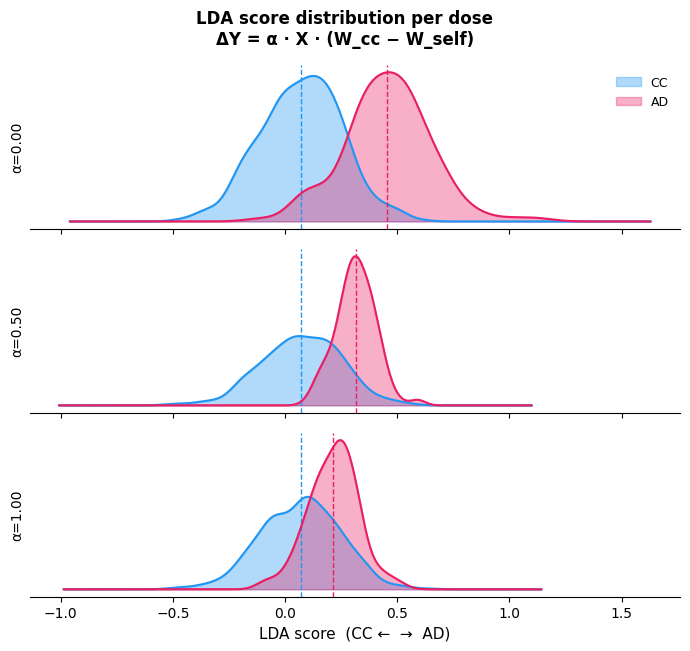

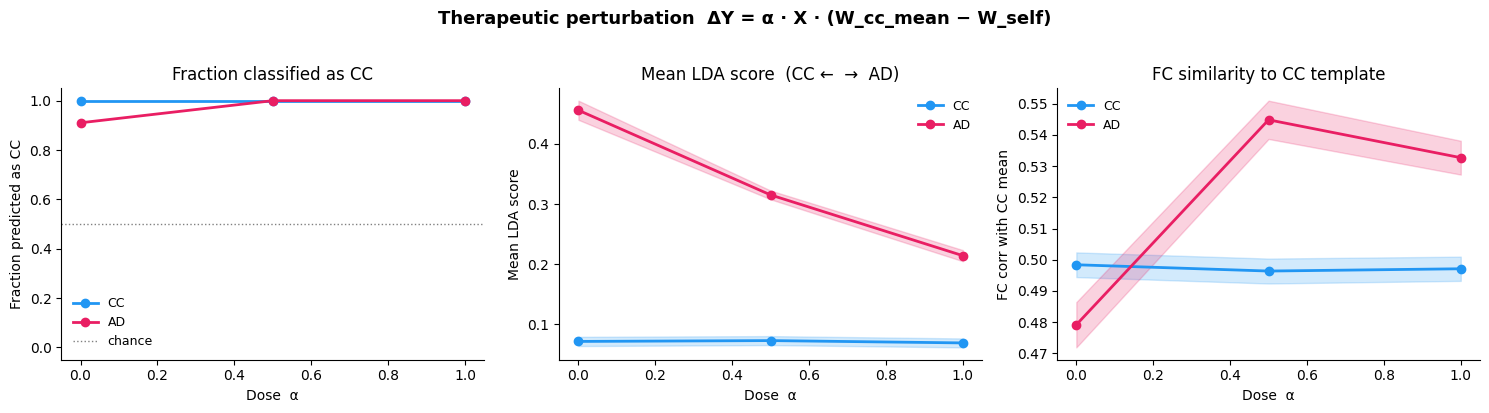


══════════════════════════════════════════════════════════
  SUMMARY  —  binary CC vs AD
══════════════════════════════════════════════════════════
      α     CC→CC     AD→CC    LDA(CC)    LDA(AD)   FC-corr(AD)
   0.00     1.000     0.910      0.072      0.456         0.479
   0.50     1.000     1.000      0.073      0.315         0.545
   1.00     1.000     1.000      0.069      0.214         0.533


In [41]:


# ── 5. Plots ───────────────────────────────────────────────────────────────
col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (1-D KDE ridgeline) ───────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

for ax, alpha in zip(axes, alpha_values):
    z     = results[alpha]['z_lda']
    x_min = z.min() - 0.5
    x_max = z.max() + 0.5
    xs    = np.linspace(x_min, x_max, 400)

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\nΔY = α · X · (W_cc − W_self)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('therapeutic_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction of AD predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose  (want AD to decrease toward CC)
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean vs dose
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Therapeutic perturbation  ΔY = α · X · (W_cc_mean − W_self)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('therapeutic_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 6. Numerical summary ───────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  binary CC vs AD")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

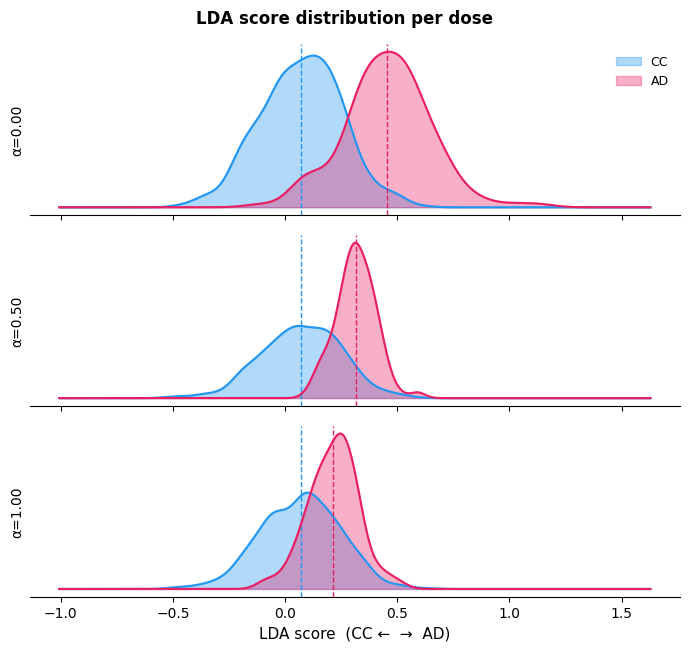

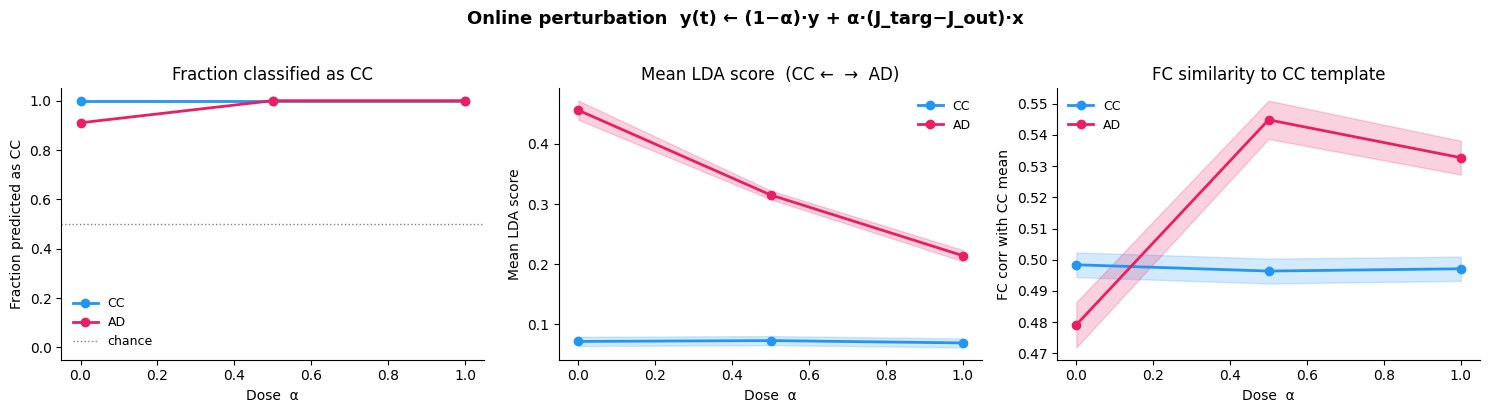

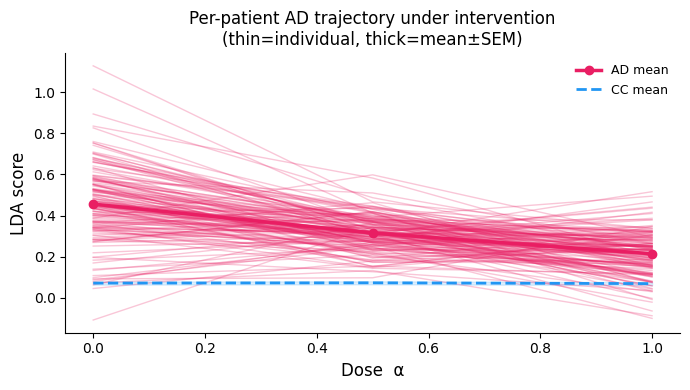


══════════════════════════════════════════════════════════
  SUMMARY — online perturbation  (CC vs AD)
══════════════════════════════════════════════════════════
      α     CC→CC     AD→CC    LDA(CC)    LDA(AD)   FC-corr(AD)
   0.00     1.000     0.910      0.072      0.456         0.479
   0.50     1.000     1.000      0.073      0.315         0.545
   1.00     1.000     1.000      0.069      0.214         0.533


: 

In [ ]:
# %%
# ============================================================
# Visualization — online perturbation dose sweep
# Expects: results, alpha_values, y_lda, ctrl_indices,
#          ad_indices, col_cc, col_ad
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

col_cc = '#2196F3'
col_ad = '#E91E63'

# ── Fig 1: ridgeline KDE of LDA scores per dose ───────────────────────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

all_z = np.concatenate([results[a]['z_lda'] for a in alpha_values])
xs    = np.linspace(all_z.min() - 0.5, all_z.max() + 0.5, 400)

for ax, alpha in zip(axes, alpha_values):
    z = results[alpha]['z_lda']
    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)
    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pert_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0) for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α'); ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score ± SEM
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α'); ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean ± SEM
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α'); ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Online perturbation  y(t) ← (1−α)·y + α·(J_targ−J_out)·x',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 3: per-patient LDA score trajectories (AD only) ───────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ad_mask = (y_lda == 1)
for i in range(ad_mask.sum()):
    traj = [results[a]['z_lda'][ad_mask][i] for a in alpha_values]
    ax.plot(alpha_values, traj, '-', color=col_ad, alpha=0.25, linewidth=1)

# mean ± SEM on top
means = [results[a]['z_lda'][ad_mask].mean() for a in alpha_values]
sems  = [results[a]['z_lda'][ad_mask].std() / np.sqrt(ad_mask.sum())
         for a in alpha_values]
ax.plot(alpha_values, means, '-o', color=col_ad, linewidth=2.5, label='AD mean')
ax.fill_between(alpha_values,
                np.array(means) - np.array(sems),
                np.array(means) + np.array(sems),
                color=col_ad, alpha=0.25)

# CC reference band
cc_scores = [results[a]['z_lda'][y_lda == 0].mean() for a in alpha_values]
cc_sems   = [results[a]['z_lda'][y_lda == 0].std() /
             np.sqrt((y_lda == 0).sum()) for a in alpha_values]
ax.plot(alpha_values, cc_scores, '--', color=col_cc, linewidth=2, label='CC mean')
ax.fill_between(alpha_values,
                np.array(cc_scores) - np.array(cc_sems),
                np.array(cc_scores) + np.array(cc_sems),
                color=col_cc, alpha=0.15)

ax.set_xlabel('Dose  α', fontsize=12)
ax.set_ylabel('LDA score', fontsize=12)
ax.set_title('Per-patient AD trajectory under intervention\n(thin=individual, thick=mean±SEM)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pert_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY — online perturbation  (CC vs AD)")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [ ]:
# %%
# ============================================================
# Dose sweep — single-site perturbation (AD only)
#
# The perturbation (J_targ - J_out) is masked to a single site:
# the one with the largest column norm in (W_targ - W_new),
# i.e. the site where the AD→CC weight difference is largest.
# All other sites: J_targ[:,site] = J_out[:,site]  → delta=0
# ============================================================

alpha_values = [0.0, 5.0, 10.0]
noise_size   = 0.025 * 0.5 * 0.5

results = {a: dict(g_new=[], fc_corr_ctrl=[],
                   z_lda=None, y_pred=None, top_site=[])
           for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   single-site perturbation  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []
    top_site_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Refit W_self ────────────────────────────────────────────────
        W_self = fitted_weights_list[patient]              # [N_res, N_sites]
        W_new  = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]
        W_targ = fitted_weights_list[ctrl_indices[np.random.randint(len(ctrl_indices))]]

        # ── d. Build single-site masked J_targ ────────────────────────────
        network_reservoire.Jout  = np.copy(W_new.T)       # [N_sites, N_res]
        network_reservoire.alpha = alpha

        if is_ad:
            # column norm of dW: importance of each site  [N_sites]
            dW          = W_targ - W_new                  # [N_res, N_sites]
            site_importance = np.linalg.norm(dW, axis=0)  # [N_sites]
            top_site    = np.argmax(site_importance)

            # J_targ = W_new everywhere except at top_site
            W_targ_masked           = np.copy(W_new)
            W_targ_masked[:, top_site] = W_targ[:, top_site]

            network_reservoire.J_targ = np.copy(W_targ_masked.T)  # [N_sites, N_res]
            apply_perturbation = True
            top_site_list.append(top_site)
        else:
            network_reservoire.J_targ = np.copy(W_new.T)  # delta = 0
            apply_perturbation = False
            top_site_list.append(-1)

        # ── e. Autonomous run with single-site perturbation ────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
            perturbation    = apply_perturbation,
        )

        # ── f. Re-estimate W from simulated activity → g_new ──────────────
        norm_mua_target = network_reservoire.data.T        # [N_sites, T']
        network_reservoire.T = norm_mua_target.shape[1]
        network_reservoire.reset()

        X_aut, Y_aut = train_test_pinv(feedback_factor=recurrent_factor)
        X_aut = np.array(X_aut)[10:, :]
        Y_aut = np.array(Y_aut)[10:, :]

        W_fitted = np.linalg.pinv(
            X_aut + np.random.normal(0, noise_size, size=X_aut.shape)
        ).dot(Y_aut)                                       # [N_res, N_sites]

        w_centered = W_fitted.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results[alpha]['g_new']        = np.array(g_list)
    results[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)
    results[alpha]['top_site']     = top_site_list

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results[alpha]['z_lda']  = z_new
    results[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")

    # report most commonly targeted site at this dose
    ad_sites = [s for s, c in zip(top_site_list, state_ID_numeric) if c == 4]
    vals, counts = np.unique(ad_sites, return_counts=True)
    top3 = vals[np.argsort(counts)[-3:][::-1]]
    print(f"  Top-3 targeted sites: {top3}")


────────────────────────────────────────────────────────────
  α = 0.00   single-site perturbation  [AD only]
────────────────────────────────────────────────────────────


  0%|          | 0/702 [00:00<?, ?it/s]

(139, 2000) (139, 121)
(137, 2000) (137, 121)


  0%|          | 2/702 [00:00<02:46,  4.22it/s]

(139, 2000) (139, 121)
(137, 2000) (137, 121)


...

(139, 2000) (139, 121)
(137, 2000) (137, 121)
(199, 2000) (199, 121)
(137, 2000) (137, 121)


 58%|█████▊    | 408/702 [01:38<01:15,  3.87it/s]

(139, 2000) (139, 121)
(137, 2000) (137, 121)


 58%|█████▊    | 409/702 [01:38<01:14,  3.92it/s]

(139, 2000) (139, 121)
(137, 2000) (137, 121)


In [ ]:
# %%
# ============================================================
# Visualization — single-site perturbation dose sweep
# Expects: results, alpha_values, y_lda, ctrl_indices,
#          ad_indices, state_ID_numeric, labels (Schaefer)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

col_cc = '#2196F3'
col_ad = '#E91E63'

# ── Fig 1: ridgeline KDE of LDA scores per dose ───────────────────────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

all_z = np.concatenate([results[a]['z_lda'] for a in alpha_values])
xs    = np.linspace(all_z.min() - 0.5, all_z.max() + 0.5, 400)

for ax, alpha in zip(axes, alpha_values):
    z = results[alpha]['z_lda']
    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)
    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\n(single-site perturbation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pert_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0) for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α'); ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α'); ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α'); ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Single-site perturbation  —  dose-response',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 3: per-patient AD trajectories ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ad_mask = (y_lda == 1)
for i in range(ad_mask.sum()):
    traj = [results[a]['z_lda'][ad_mask][i] for a in alpha_values]
    ax.plot(alpha_values, traj, '-', color=col_ad, alpha=0.25, linewidth=1)

means = [results[a]['z_lda'][ad_mask].mean() for a in alpha_values]
sems  = [results[a]['z_lda'][ad_mask].std() / np.sqrt(ad_mask.sum())
         for a in alpha_values]
ax.plot(alpha_values, means, '-o', color=col_ad, linewidth=2.5, label='AD mean')
ax.fill_between(alpha_values,
                np.array(means) - np.array(sems),
                np.array(means) + np.array(sems),
                color=col_ad, alpha=0.25)

cc_scores = [results[a]['z_lda'][y_lda == 0].mean() for a in alpha_values]
cc_sems   = [results[a]['z_lda'][y_lda == 0].std() /
             np.sqrt((y_lda == 0).sum()) for a in alpha_values]
ax.plot(alpha_values, cc_scores, '--', color=col_cc, linewidth=2, label='CC mean')
ax.fill_between(alpha_values,
                np.array(cc_scores) - np.array(cc_sems),
                np.array(cc_scores) + np.array(cc_sems),
                color=col_cc, alpha=0.15)

ax.set_xlabel('Dose  α', fontsize=12); ax.set_ylabel('LDA score', fontsize=12)
ax.set_title('Per-patient AD trajectory\n(thin=individual, thick=mean±SEM)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pert_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 4: targeted site analysis ─────────────────────────────────────────
# collect top_site per AD patient from any non-zero alpha (all doses give same site)
alpha_nonzero  = [a for a in alpha_values if a > 0][0]
top_sites_ad   = [s for s, c in zip(results[alpha_nonzero]['top_site'],
                                     state_ID_numeric) if c == 4]

# mean dW column norm across AD patients (site importance)
site_importance_all = []
for patient in ad_indices:
    W_self_ = fitted_weights_list[patient]
    W_targ_ = fitted_weights_list[ctrl_indices[0]]  # representative CC
    dW_     = W_targ_ - W_self_
    site_importance_all.append(np.linalg.norm(dW_, axis=0))

site_importance_mean = np.mean(site_importance_all, axis=0)  # [N_sites]
top5 = np.argsort(site_importance_mean)[-5:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 0 — histogram of top targeted site per AD patient
ax = axes[0]
ax.hist(top_sites_ad, bins=N_sites, color=col_ad, alpha=0.7, edgecolor='none')
for s in top5:
    ax.axvline(s, color='#880E4F', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Number of AD patients')
ax.set_title('Most targeted site per AD patient\n(dashed = population top-5)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean site importance bar chart
ax = axes[1]
ax.bar(range(N_sites), site_importance_mean,
       color=col_ad, alpha=0.5, width=1.0, edgecolor='none')
for s in top5:
    ax.bar(s, site_importance_mean[s], color='#880E4F', alpha=0.9, width=1.0)

ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Mean ||dW||  column norm')
ax.set_title('Site importance  (top-5 in dark red)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# annotate top-5
for s in top5:
    try:
        lbl = labels[s].decode() if hasattr(labels[s], 'decode') else str(labels[s])
        ax.text(s, site_importance_mean[s] * 1.02, lbl,
                fontsize=5, ha='center', va='bottom', rotation=90)
    except Exception:
        pass

fig.suptitle('Single-site targeting — site importance across AD patients',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_site_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop-5 most targeted sites:")
for rank, s in enumerate(top5):
    try:
        lbl = labels[s].decode() if hasattr(labels[s], 'decode') else str(labels[s])
    except Exception:
        lbl = str(s)
    n_targeted = top_sites_ad.count(s)
    print(f"  {rank+1}. site {s:3d}  ({lbl})  "
          f"importance={site_importance_mean[s]:.4f}  "
          f"targeted by {n_targeted}/{len(top_sites_ad)} AD patients")


# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY — single-site perturbation  (CC vs AD)")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [ ]:
# %%
# ============================================================
# Dose sweep — TOP-5-site perturbation (AD only)
#
# The perturbation (J_targ - J_out) is masked to a single site:
# the one with the largest column norm in (W_targ - W_new),
# i.e. the site where the AD→CC weight difference is largest.
# All other sites: J_targ[:,site] = J_out[:,site]  → delta=0
# ============================================================

alpha_values = [0.0, 0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

results = {a: dict(g_new=[], fc_corr_ctrl=[],
                   z_lda=None, y_pred=None, top_site=[])
           for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   single-site perturbation  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []
    top_site_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Refit W_self ────────────────────────────────────────────────
        W_self = fitted_weights_list[patient]              # [N_res, N_sites]
        W_new  = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]
        W_targ = fitted_weights_list[ctrl_indices[np.random.randint(len(ctrl_indices))]]

        # ── d. Build single-site masked J_targ ────────────────────────────
        network_reservoire.Jout  = np.copy(W_new.T)       # [N_sites, N_res]
        network_reservoire.alpha = alpha

        if is_ad:
            # column norm of dW: importance of each site  [N_sites]
            dW              = W_targ - W_new                    # [N_res, N_sites]
            site_importance = np.linalg.norm(dW, axis=0)        # [N_sites]
            top5_sites      = np.argsort(site_importance)[-10:]  # top-5 by importance

            # J_targ = W_new everywhere except at top5_sites
            W_targ_masked = np.copy(W_new)
            W_targ_masked[:, top5_sites] = W_targ[:, top5_sites]

            network_reservoire.J_targ = np.copy(W_targ_masked.T)  # [N_sites, N_res]
            apply_perturbation = True
            top_site_list.append(top5_sites)
        else:
            network_reservoire.J_targ = np.copy(W_new.T)  # delta = 0
            apply_perturbation = False
            top_site_list.append(-1)

        # ── e. Autonomous run with single-site perturbation ────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
            perturbation    = apply_perturbation,
        )

        # ── f. Re-estimate W from simulated activity → g_new ──────────────
        norm_mua_target = network_reservoire.data.T        # [N_sites, T']
        network_reservoire.T = norm_mua_target.shape[1]
        network_reservoire.reset()

        X_aut, Y_aut = train_test_pinv(feedback_factor=recurrent_factor)
        X_aut = np.array(X_aut)[10:, :]
        Y_aut = np.array(Y_aut)[10:, :]

        W_fitted = np.linalg.pinv(
            X_aut + np.random.normal(0, noise_size, size=X_aut.shape)
        ).dot(Y_aut)                                       # [N_res, N_sites]

        w_centered = W_fitted.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results[alpha]['g_new']        = np.array(g_list)
    results[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)
    results[alpha]['top_site']     = top_site_list

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results[alpha]['z_lda']  = z_new
    results[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")

    # report most commonly targeted sites at this dose
    ad_sites_flat = np.concatenate([s for s, c in zip(top_site_list, state_ID_numeric)
                                    if c == 4])
    vals, counts  = np.unique(ad_sites_flat, return_counts=True)
    top3          = vals[np.argsort(counts)[-3:][::-1]]
    print(f"  Top-3 most frequently targeted sites: {top3}")

In [ ]:
np.shape(W_targ_masked)

In [ ]:
# %%
# ============================================================
# Visualization — single-site perturbation dose sweep
# Expects: results, alpha_values, y_lda, ctrl_indices,
#          ad_indices, state_ID_numeric, labels (Schaefer)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

col_cc = '#2196F3'
col_ad = '#E91E63'

# ── Fig 1: ridgeline KDE of LDA scores per dose ───────────────────────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

all_z = np.concatenate([results[a]['z_lda'] for a in alpha_values])
xs    = np.linspace(all_z.min() - 0.5, all_z.max() + 0.5, 400)

for ax, alpha in zip(axes, alpha_values):
    z = results[alpha]['z_lda']
    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)
    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\n(single-site perturbation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pert_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0) for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α'); ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α'); ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α'); ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Single-site perturbation  —  dose-response',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 3: per-patient AD trajectories ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ad_mask = (y_lda == 1)
for i in range(ad_mask.sum()):
    traj = [results[a]['z_lda'][ad_mask][i] for a in alpha_values]
    ax.plot(alpha_values, traj, '-', color=col_ad, alpha=0.25, linewidth=1)

means = [results[a]['z_lda'][ad_mask].mean() for a in alpha_values]
sems  = [results[a]['z_lda'][ad_mask].std() / np.sqrt(ad_mask.sum())
         for a in alpha_values]
ax.plot(alpha_values, means, '-o', color=col_ad, linewidth=2.5, label='AD mean')
ax.fill_between(alpha_values,
                np.array(means) - np.array(sems),
                np.array(means) + np.array(sems),
                color=col_ad, alpha=0.25)

cc_scores = [results[a]['z_lda'][y_lda == 0].mean() for a in alpha_values]
cc_sems   = [results[a]['z_lda'][y_lda == 0].std() /
             np.sqrt((y_lda == 0).sum()) for a in alpha_values]
ax.plot(alpha_values, cc_scores, '--', color=col_cc, linewidth=2, label='CC mean')
ax.fill_between(alpha_values,
                np.array(cc_scores) - np.array(cc_sems),
                np.array(cc_scores) + np.array(cc_sems),
                color=col_cc, alpha=0.15)

ax.set_xlabel('Dose  α', fontsize=12); ax.set_ylabel('LDA score', fontsize=12)
ax.set_title('Per-patient AD trajectory\n(thin=individual, thick=mean±SEM)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pert_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 4: targeted site analysis ─────────────────────────────────────────
# read top5_sites directly from results (each entry is a length-5 array)
alpha_nonzero     = [a for a in alpha_values if a > 0][0]
top5_sites_ad     = [s for s, c in zip(results[alpha_nonzero]['top_site'],
                                        state_ID_numeric) if c == 4]
all_targeted_flat = np.concatenate(top5_sites_ad)   # [n_AD * 5]

# site importance: mean column norm of dW across AD patients
# use W_cc_mean as target (population-level, avoids random seed dependence)
site_importance_all = []
for patient in ad_indices:
    W_self_ = fitted_weights_list[patient]
    dW_     = W_cc_mean - W_self_
    site_importance_all.append(np.linalg.norm(dW_, axis=0))

site_importance_mean = np.mean(site_importance_all, axis=0)  # [N_sites]
top5_pop = np.argsort(site_importance_mean)[-5:][::-1]       # population top-5

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 0 — histogram of all targeted sites across AD patients
ax = axes[0]
ax.hist(all_targeted_flat, bins=N_sites, color=col_ad, alpha=0.7, edgecolor='none')
for s in top5_pop:
    ax.axvline(s, color='#880E4F', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Count across AD patients')
ax.set_title('Top-5 targeted sites per AD patient\n(dashed = population top-5)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean site importance bar chart, top-5 highlighted
ax = axes[1]
ax.bar(range(N_sites), site_importance_mean,
       color=col_ad, alpha=0.4, width=1.0, edgecolor='none')
for s in top5_pop:
    ax.bar(s, site_importance_mean[s], color='#880E4F', alpha=0.95, width=1.0)

ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Mean ||dW||  column norm')
ax.set_title('Site importance  (top-5 highlighted)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for s in top5_pop:
    try:
        lbl = labels[s].decode() if hasattr(labels[s], 'decode') else str(labels[s])
        ax.text(s, site_importance_mean[s] * 1.02, lbl,
                fontsize=5, ha='center', va='bottom', rotation=90)
    except Exception:
        pass

fig.suptitle('Top-5 importance sites — AD patients',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_site_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# frequency table: how often each site appears in the top-5 across AD patients
vals, counts = np.unique(all_targeted_flat, return_counts=True)
top_ranked   = vals[np.argsort(counts)[-10:][::-1]]
print(f"Top-10 most frequently targeted sites (across all AD patients):")
for s in top_ranked:
    try:
        lbl = labels[s].decode() if hasattr(labels[s], 'decode') else str(labels[s])
    except Exception:
        lbl = str(s)
    freq = counts[vals == s][0]
    print(f"  site {s:3d}  ({lbl})  "
          f"importance={site_importance_mean[s]:.4f}  "
          f"freq={freq}/{len(top5_sites_ad)} AD patients")


# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY — top-5 site perturbation  (CC vs AD)")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [ ]:
# %%
# ============================================================
# Dose sweep — perturbation version
#
# Jout stays as W_self (original readout, never interpolated).
# The perturbation inside train_test nudges y(t) at every step:
#   y(t) ← (1-α)·y(t) + α·(J_targ − J_out) @ X(t)
# After the autonomous run, W is re-estimated from the
# resulting simulated activity (same as interpolation version).
#
# AD only: J_targ = nearest CC in g-space
# CC     : no perturbation (J_targ = J_out → delta = 0)
# ============================================================

alpha_values = [0.0, 0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

# nearest-CC lookup in g-space
G_cc = G_scores[ctrl_indices]   # [n_CC, M]

def nearest_cc(patient_idx):
    g_self = G_scores[patient_idx]
    dists  = np.linalg.norm(G_cc - g_self, axis=1)
    nn     = np.argmin(dists)
    return ctrl_indices[nn]     # global index into fitted_weights_list

results_pert = {a: dict(g_new=[], fc_corr_ctrl=[],
                        z_lda=None, y_pred=None)
                for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   online perturbation in train_test  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Fit W_self from driven phase ───────────────────────────────
        W_new = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]

        # ── d. Set Jout (always W_self) and perturbation target ───────────
        network_reservoire.Jout  = np.copy(W_new.T)       # [N_sites, N_res]
        network_reservoire.alpha = alpha

        if is_ad:
            #nn_global = nearest_cc(patient)
            #W_targ    = fitted_weights_list[nn_global]     # [N_res, N_sites]
            #W_targ = np.mean([fitted_weights_list[i] for i in ctrl_indices], axis=0)
            W_targ = fitted_weights_list[ctrl_indices[np.random.randint(len(ctrl_indices))]]
            network_reservoire.J_targ = np.copy(W_targ.T) # [N_sites, N_res]
            apply_perturbation = True
        else:
            network_reservoire.J_targ = np.copy(W_new.T)  # delta = 0
            apply_perturbation = False

        # ── e. Autonomous run with online perturbation ─────────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
            perturbation    = apply_perturbation,
        )

        # ── f. Re-estimate W from the simulated activity → g_new ──────────
        norm_mua_target = network_reservoire.data.T        # [N_sites, T']
        network_reservoire.T = norm_mua_target.shape[1]
        network_reservoire.reset()

        X_aut, Y_aut = train_test_pinv(feedback_factor=recurrent_factor)
        X_aut = np.array(X_aut)[10:, :]   # [T', N_res]
        Y_aut = np.array(Y_aut)[10:, :]   # [T', N_sites]

        W_fitted = np.linalg.pinv(
            X_aut + np.random.normal(0, noise_size, size=X_aut.shape)
        ).dot(Y_aut)                       # [N_res, N_sites]

        w_centered = W_fitted.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results_pert[alpha]['g_new']        = np.array(g_list)
    results_pert[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results_pert[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results_pert[alpha]['z_lda']  = z_new
    results_pert[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")

In [ ]:
# %%
# ============================================================
# Visualization — single-site LDA-projected perturbation
# Uses results_pert from dose_sweep_perturbation.py
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (ridgeline) ───────────────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

# global x range across all doses
all_z = np.concatenate([results_pert[a]['z_lda'] for a in alpha_values])
xs    = np.linspace(all_z.min() - 0.5, all_z.max() + 0.5, 400)

for ax, alpha in zip(axes, alpha_values):
    z = results_pert[alpha]['z_lda']

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\n'
             'single-site LDA-projected perturbation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pert_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results_pert[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results_pert[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results_pert[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results_pert[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results_pert[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Single-site LDA-projected perturbation  —  dose-response',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 3: top targeted site across AD patients ────────────────────────────
# Recompute site_importance for each AD patient (alpha-independent, uses dW_lda)
site_importance_all = []

for patient in ad_indices:
    W_self_ = fitted_weights_list[patient]
    W_targ_ = np.mean([fitted_weights_list[i] for i in ctrl_indices], axis=0)
    dW_     = W_targ_ - W_self_

    scale_       = np.sum(dW_ * w_dir_matrix)
    dW_lda_      = scale_ * w_dir_matrix                   # [N_res, N_sites]
    site_imp_    = np.linalg.norm(dW_lda_, axis=0)        # [N_sites]
    site_importance_all.append(site_imp_)

site_importance_all = np.array(site_importance_all)        # [n_AD, N_sites]
top_sites           = np.argmax(site_importance_all, axis=1)  # [n_AD]
mean_importance     = site_importance_all.mean(axis=0)        # [N_sites]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 0 — histogram of top targeted site per AD patient
ax = axes[0]
ax.hist(top_sites, bins=N_sites, color=col_ad, alpha=0.7, edgecolor='none')
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Number of AD patients')
ax.set_title('Most targeted site per AD patient\n(argmax of LDA-projected site importance)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean site importance across AD patients
ax = axes[1]
ax.bar(range(N_sites), mean_importance, color=col_ad, alpha=0.7, width=1.0)
top5 = np.argsort(mean_importance)[-5:][::-1]
for s in top5:
    ax.bar(s, mean_importance[s], color='#880E4F', alpha=0.9, width=1.0)
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Mean |dW_lda| column norm')
ax.set_title('Mean site importance across AD patients\n(top-5 highlighted)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# annotate top-5 with region labels if available
try:
    for s in top5:
        ax.text(s, mean_importance[s], f' {labels[s].decode()}',
                fontsize=6, va='bottom', rotation=90)
except Exception:
    pass

fig.suptitle('Single-site targeting — site importance map',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_site_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop-5 most important sites (mean across AD patients):")
for rank, s in enumerate(top5):
    try:
        label = labels[s].decode()
    except Exception:
        label = str(s)
    print(f"  {rank+1}. site {s:3d}  ({label})  importance={mean_importance[s]:.4f}")


# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  single-site LDA perturbation  (CC vs AD)")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results_pert[a]['z_lda']
    pred = results_pert[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results_pert[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [ ]:
# %% Only direction parallel to LDA
# ============================================================
# Dose sweep — perturbation version
#
# Jout stays as W_self (original readout, never interpolated).
# The perturbation inside train_test nudges y(t) at every step:
#   y(t) ← (1-α)·y(t) + α·(J_targ − J_out) @ X(t)
# After the autonomous run, W is re-estimated from the
# resulting simulated activity (same as interpolation version).
#
# AD only: J_targ = nearest CC in g-space
# CC     : no perturbation (J_targ = J_out → delta = 0)
# ============================================================

alpha_values = [0.0,  0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

# nearest-CC lookup in g-space
G_cc = G_scores[ctrl_indices]   # [n_CC, M]

def nearest_cc(patient_idx):
    g_self = G_scores[patient_idx]
    dists  = np.linalg.norm(G_cc - g_self, axis=1)
    nn     = np.argmin(dists)
    return ctrl_indices[nn]     # global index into fitted_weights_list

# ── LDA discriminant direction mapped back to weight space (precomputed) ──
# lda_ref.scalings_ : [M, 1]  discriminant axis in g-space
v_lda        = lda_ref.scalings_[:, 0]                 # [M]
v_lda        = v_lda / np.linalg.norm(v_lda)           # unit vector in g-space
# Vt_s[:M] : [M, N_out*N_in]  — archetype basis in weight space
w_dir        = v_lda @ Vt_s[:M]                        # [N_out*N_in]
w_dir_norm   = w_dir / np.linalg.norm(w_dir)           # unit vector in W-space
# reshape: SVD was done on W.T.flatten() where W.T is [N_out, N_in]
w_dir_matrix = w_dir_norm.reshape(N_out, N_in).T       # [N_res, N_sites]

results_pert = {a: dict(g_new=[], fc_corr_ctrl=[],
                        z_lda=None, y_pred=None)
                for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   online perturbation in train_test  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Fit W_self from driven phase ───────────────────────────────
        W_new = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]

        # ── d. Set Jout (always W_self) and perturbation target ───────────
        network_reservoire.Jout  = np.copy(W_new.T)       # [N_sites, N_res]
        network_reservoire.alpha = alpha

        if is_ad:
            W_targ = fitted_weights_list[ctrl_indices[np.random.randint(len(ctrl_indices))]]
            #W_targ = np.mean([fitted_weights_list[i] for i in ctrl_indices], axis=0)
            dW     = W_targ - W_new                        # [N_res, N_sites]

            # project dW onto the LDA discriminant direction in weight space
            # → minimal perturbation that moves the patient across the boundary
            scale    = np.sum(dW * w_dir_matrix)           # scalar alignment
            dW_lda   = scale * w_dir_matrix                # [N_res, N_sites]

            network_reservoire.J_targ = np.copy((W_new + dW_lda).T)  # [N_sites, N_res]
            apply_perturbation = True
        else:
            network_reservoire.J_targ = np.copy(W_new.T)  # delta = 0
            apply_perturbation = False

        # ── e. Autonomous run with online perturbation ─────────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
            perturbation    = apply_perturbation,
        )

        # ── f. Re-estimate W from the simulated activity → g_new ──────────
        norm_mua_target = network_reservoire.data.T        # [N_sites, T']
        network_reservoire.T = norm_mua_target.shape[1]
        network_reservoire.reset()

        X_aut, Y_aut = train_test_pinv(feedback_factor=recurrent_factor)
        X_aut = np.array(X_aut)[10:, :]   # [T', N_res]
        Y_aut = np.array(Y_aut)[10:, :]   # [T', N_sites]

        W_fitted = np.linalg.pinv(
            X_aut + np.random.normal(0, noise_size, size=X_aut.shape)
        ).dot(Y_aut)                       # [N_res, N_sites]

        w_centered = W_fitted.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results_pert[alpha]['g_new']        = np.array(g_list)
    results_pert[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results_pert[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results_pert[alpha]['z_lda']  = z_new
    results_pert[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")

In [ ]:


# ── 5. Plots ───────────────────────────────────────────────────────────────
col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (1-D KDE ridgeline) ───────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

for ax, alpha in zip(axes, alpha_values):
    z     = results[alpha]['z_lda']
    x_min = z.min() - 0.5
    x_max = z.max() + 0.5
    xs    = np.linspace(x_min, x_max, 400)

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\nΔY = α · X · (W_cc − W_self)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('therapeutic_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction of AD predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose  (want AD to decrease toward CC)
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean vs dose
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Therapeutic perturbation  ΔY = α · X · (W_cc_mean − W_self)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('therapeutic_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 6. Numerical summary ───────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  binary CC vs AD")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results[a]['z_lda']
    pred = results[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [ ]:
# %% ONLY ONE SITE!!!!!
# ============================================================
# Dose sweep — perturbation version
#
# Jout stays as W_self (original readout, never interpolated).
# The perturbation inside train_test nudges y(t) at every step:
#   y(t) ← (1-α)·y(t) + α·(J_targ − J_out) @ X(t)
# After the autonomous run, W is re-estimated from the
# resulting simulated activity (same as interpolation version).
#
# AD only: J_targ = nearest CC in g-space
# CC     : no perturbation (J_targ = J_out → delta = 0)
# ============================================================

alpha_values = [0.0, 0.25, 0.5, 1.0]
noise_size   = 0.025 * 0.5 * 0.5

# nearest-CC lookup in g-space
G_cc = G_scores[ctrl_indices]   # [n_CC, M]

def nearest_cc(patient_idx):
    g_self = G_scores[patient_idx]
    dists  = np.linalg.norm(G_cc - g_self, axis=1)
    nn     = np.argmin(dists)
    return ctrl_indices[nn]     # global index into fitted_weights_list

# ── LDA discriminant direction mapped back to weight space (precomputed) ──
# lda_ref.scalings_ : [M, 1]  discriminant axis in g-space
v_lda        = lda_ref.scalings_[:, 0]                 # [M]
v_lda        = v_lda / np.linalg.norm(v_lda)           # unit vector in g-space
# Vt_s[:M] : [M, N_out*N_in]  — archetype basis in weight space
w_dir        = v_lda @ Vt_s[:M]                        # [N_out*N_in]
w_dir_norm   = w_dir / np.linalg.norm(w_dir)           # unit vector in W-space
# reshape: SVD was done on W.T.flatten() where W.T is [N_out, N_in]
w_dir_matrix = w_dir_norm.reshape(N_out, N_in).T       # [N_res, N_sites]

results_pert = {a: dict(g_new=[], fc_corr_ctrl=[],
                        z_lda=None, y_pred=None)
                for a in alpha_values}

for alpha in alpha_values:
    print(f"\n{'─'*60}")
    print(f"  α = {alpha:.2f}   online perturbation in train_test  [AD only]")
    print(f"{'─'*60}")

    g_list       = []
    fc_corr_list = []

    for patient in trange(len(concatenated_signals_list)):

        is_ad = (state_ID_numeric[patient] == 4)

        # ── a. Driving signal ──────────────────────────────────────────────
        data = np.copy(concatenated_signals_list[patient])
        network_reservoire.T = data.shape[1]
        network_reservoire.reset()

        ev5             = sorted_eigenvectors_common[:, :50]
        norm_mua_target = np.dot(np.dot(data.T, ev5), ev5.T).T  # [N_sites, T]

        # ── b. Driven run → collect X, Y ──────────────────────────────────
        X_raw, Y_raw = train_test_pinv(feedback_factor=recurrent_factor)
        X = np.array(X_raw)[10:, :]    # [T', N_res]
        Y = np.array(Y_raw)[10:, :]    # [T', N_sites]

        # ── c. Fit W_self from driven phase ───────────────────────────────
        W_new = np.linalg.pinv(
            X + np.random.normal(0, noise_size, size=X.shape)
        ).dot(Y)                                           # [N_res, N_sites]

        # ── d. Set Jout (always W_self) and perturbation target ───────────
        network_reservoire.Jout  = np.copy(W_new.T)       # [N_sites, N_res]
        network_reservoire.alpha = alpha

        if is_ad:
            W_targ = np.mean([fitted_weights_list[i] for i in ctrl_indices], axis=0)
            dW     = W_targ - W_new                        # [N_res, N_sites]

            # project dW onto the LDA discriminant direction in weight space
            # → minimal perturbation that moves the patient across the boundary
            scale    = np.sum(dW * w_dir_matrix)           # scalar alignment
            dW_lda   = scale * w_dir_matrix                # [N_res, N_sites]

            # ── single-site masking: keep only the most important site ─────
            # importance = L2 norm of each site's column in dW_lda
            site_importance = np.linalg.norm(dW_lda, axis=0)  # [N_sites]
            top_site        = np.argmax(site_importance)

            dW_lda_masked           = np.zeros_like(dW_lda)
            dW_lda_masked[:, top_site] = dW_lda[:, top_site]  # [N_res, N_sites]

            network_reservoire.J_targ = np.copy((W_new + dW_lda_masked).T)  # [N_sites, N_res]
            apply_perturbation = True
        else:
            network_reservoire.J_targ = np.copy(W_new.T)  # delta = 0
            apply_perturbation = False

        # ── e. Autonomous run with online perturbation ─────────────────────
        train_test(
            1,
            sigma_noise_dyn = 0.0,
            feedback_factor = recurrent_factor,
            if_plot_results = False,
            perturbation    = apply_perturbation,
        )

        # ── f. Re-estimate W from the simulated activity → g_new ──────────
        norm_mua_target = network_reservoire.data.T        # [N_sites, T']
        network_reservoire.T = norm_mua_target.shape[1]
        network_reservoire.reset()

        X_aut, Y_aut = train_test_pinv(feedback_factor=recurrent_factor)
        X_aut = np.array(X_aut)[10:, :]   # [T', N_res]
        Y_aut = np.array(Y_aut)[10:, :]   # [T', N_sites]

        W_fitted = np.linalg.pinv(
            X_aut + np.random.normal(0, noise_size, size=X_aut.shape)
        ).dot(Y_aut)                       # [N_res, N_sites]

        w_centered = W_fitted.T.flatten() - W_mean.flatten()
        g_new      = w_centered @ Vt_s[:M].T              # [M]
        g_list.append(g_new)

        fc_sim = np.nan_to_num(np.corrcoef(network_reservoire.data.T))
        fc_corr_list.append(
            np.corrcoef(fc_sim.flatten(), fc_ctrl_mean)[0, 1]
        )

    results_pert[alpha]['g_new']        = np.array(g_list)
    results_pert[alpha]['fc_corr_ctrl'] = np.array(fc_corr_list)

    # ── g. LDA projection & classification ────────────────────────────────
    G_new  = results_pert[alpha]['g_new'][keep_lda]
    z_new  = lda_ref.transform(G_new).ravel()
    y_pred = lda_ref.predict(G_new)

    results_pert[alpha]['z_lda']  = z_new
    results_pert[alpha]['y_pred'] = y_pred

    for cls, name in [(0, 'CC'), (1, 'AD')]:
        mask    = (y_lda == cls)
        frac_cc = np.mean(y_pred[mask] == 0)
        print(f"  {name}  (n={mask.sum():3d})  frac→CC={frac_cc:.3f}  "
              f"LDA mean={z_new[mask].mean():.3f}")

In [ ]:
# %%
# ============================================================
# Visualization — single-site LDA-projected perturbation
# Uses results_pert from dose_sweep_perturbation.py
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (ridgeline) ───────────────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

# global x range across all doses
all_z = np.concatenate([results_pert[a]['z_lda'] for a in alpha_values])
xs    = np.linspace(all_z.min() - 0.5, all_z.max() + 0.5, 400)

for ax, alpha in zip(axes, alpha_values):
    z = results_pert[alpha]['z_lda']

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\n'
             'single-site LDA-projected perturbation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pert_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results_pert[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results_pert[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results_pert[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results_pert[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results_pert[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Single-site LDA-projected perturbation  —  dose-response',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 3: top targeted site across AD patients ────────────────────────────
# Recompute site_importance for each AD patient (alpha-independent, uses dW_lda)
site_importance_all = []

for patient in ad_indices:
    W_self_ = fitted_weights_list[patient]
    W_targ_ = np.mean([fitted_weights_list[i] for i in ctrl_indices], axis=0)
    dW_     = W_targ_ - W_self_

    scale_       = np.sum(dW_ * w_dir_matrix)
    dW_lda_      = scale_ * w_dir_matrix                   # [N_res, N_sites]
    site_imp_    = np.linalg.norm(dW_lda_, axis=0)        # [N_sites]
    site_importance_all.append(site_imp_)

site_importance_all = np.array(site_importance_all)        # [n_AD, N_sites]
top_sites           = np.argmax(site_importance_all, axis=1)  # [n_AD]
mean_importance     = site_importance_all.mean(axis=0)        # [N_sites]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 0 — histogram of top targeted site per AD patient
ax = axes[0]
ax.hist(top_sites, bins=N_sites, color=col_ad, alpha=0.7, edgecolor='none')
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Number of AD patients')
ax.set_title('Most targeted site per AD patient\n(argmax of LDA-projected site importance)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean site importance across AD patients
ax = axes[1]
ax.bar(range(N_sites), mean_importance, color=col_ad, alpha=0.7, width=1.0)
top5 = np.argsort(mean_importance)[-5:][::-1]
for s in top5:
    ax.bar(s, mean_importance[s], color='#880E4F', alpha=0.9, width=1.0)
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Mean |dW_lda| column norm')
ax.set_title('Mean site importance across AD patients\n(top-5 highlighted)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# annotate top-5 with region labels if available
try:
    for s in top5:
        ax.text(s, mean_importance[s], f' {labels[s].decode()}',
                fontsize=6, va='bottom', rotation=90)
except Exception:
    pass

fig.suptitle('Single-site targeting — site importance map',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_site_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop-5 most important sites (mean across AD patients):")
for rank, s in enumerate(top5):
    try:
        label = labels[s].decode()
    except Exception:
        label = str(s)
    print(f"  {rank+1}. site {s:3d}  ({label})  importance={mean_importance[s]:.4f}")


# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  single-site LDA perturbation  (CC vs AD)")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results_pert[a]['z_lda']
    pred = results_pert[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results_pert[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")

In [ ]:
# %%
# ============================================================
# Visualization — single-site LDA-projected perturbation
# Uses results_pert from dose_sweep_perturbation.py
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

col_cc = '#2196F3'   # blue  — CC
col_ad = '#E91E63'   # pink  — AD

# ── Fig 1: LDA score distributions per dose (ridgeline) ───────────────────
fig, axes = plt.subplots(len(alpha_values), 1,
                         figsize=(7, 2.2 * len(alpha_values)),
                         sharex=True)

# global x range across all doses
all_z = np.concatenate([results_pert[a]['z_lda'] for a in alpha_values])
xs    = np.linspace(all_z.min() - 0.5, all_z.max() + 0.5, 400)

for ax, alpha in zip(axes, alpha_values):
    z = results_pert[alpha]['z_lda']

    for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
        pts = z[y_lda == cls]
        if len(pts) < 3:
            continue
        try:
            kde = gaussian_kde(pts, bw_method='scott')
        except Exception:
            _s = float(pts.std()); _s = _s if _s > 1e-10 else 1.0
            kde = gaussian_kde(pts + np.random.normal(0, _s * 1e-3 + 1e-4, pts.shape), bw_method='scott')
        ax.fill_between(xs, kde(xs), alpha=0.35, color=col, label=name)
        ax.plot(xs, kde(xs), color=col, linewidth=1.5)
        ax.axvline(pts.mean(), color=col, linestyle='--', linewidth=1)

    ax.set_ylabel(f'α={alpha:.2f}', fontsize=10)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

axes[0].legend(frameon=False, fontsize=9, loc='upper right')
axes[-1].set_xlabel('LDA score  (CC ←  →  AD)', fontsize=11)
fig.suptitle('LDA score distribution per dose\n'
             'single-site LDA-projected perturbation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pert_lda_kde.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 2: dose-response curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 0 — fraction predicted as CC
ax = axes[0]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    fracs = [np.mean(results_pert[a]['y_pred'][y_lda == cls] == 0)
             for a in alpha_values]
    ax.plot(alpha_values, fracs, '-o', color=col, label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='chance')
ax.set_xlabel('Dose  α')
ax.set_ylabel('Fraction predicted as CC')
ax.set_title('Fraction classified as CC')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean LDA score vs dose
ax = axes[1]
for cls, col, name in [(0, col_cc, 'CC'), (1, col_ad, 'AD')]:
    means = [results_pert[a]['z_lda'][y_lda == cls].mean() for a in alpha_values]
    sems  = [results_pert[a]['z_lda'][y_lda == cls].std() /
             np.sqrt((y_lda == cls).sum()) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('Mean LDA score')
ax.set_title('Mean LDA score  (CC ←  →  AD)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — FC similarity to CC mean
ax = axes[2]
for idx_list, col, name in [(ctrl_indices, col_cc, 'CC'),
                             (ad_indices,   col_ad, 'AD')]:
    means = [results_pert[a]['fc_corr_ctrl'][idx_list].mean() for a in alpha_values]
    sems  = [results_pert[a]['fc_corr_ctrl'][idx_list].std() /
             np.sqrt(len(idx_list)) for a in alpha_values]
    ax.plot(alpha_values, means, '-o', color=col, label=name, linewidth=2)
    ax.fill_between(alpha_values,
                    np.array(means) - np.array(sems),
                    np.array(means) + np.array(sems),
                    color=col, alpha=0.2)
ax.set_xlabel('Dose  α')
ax.set_ylabel('FC corr with CC mean')
ax.set_title('FC similarity to CC template')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Single-site LDA-projected perturbation  —  dose-response',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_doseresponse.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Fig 3: top targeted site across AD patients ────────────────────────────
# Recompute site_importance for each AD patient (alpha-independent, uses dW_lda)
site_importance_all = []

for patient in ad_indices:
    W_self_ = fitted_weights_list[patient]
    W_targ_ = np.mean([fitted_weights_list[i] for i in ctrl_indices], axis=0)
    dW_     = W_targ_ - W_self_

    scale_       = np.sum(dW_ * w_dir_matrix)
    dW_lda_      = scale_ * w_dir_matrix                   # [N_res, N_sites]
    site_imp_    = np.linalg.norm(dW_lda_, axis=0)        # [N_sites]
    site_importance_all.append(site_imp_)

site_importance_all = np.array(site_importance_all)        # [n_AD, N_sites]
top_sites           = np.argmax(site_importance_all, axis=1)  # [n_AD]
mean_importance     = site_importance_all.mean(axis=0)        # [N_sites]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 0 — histogram of top targeted site per AD patient
ax = axes[0]
ax.hist(top_sites, bins=N_sites, color=col_ad, alpha=0.7, edgecolor='none')
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Number of AD patients')
ax.set_title('Most targeted site per AD patient\n(argmax of LDA-projected site importance)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 1 — mean site importance across AD patients
ax = axes[1]
ax.bar(range(N_sites), mean_importance, color=col_ad, alpha=0.7, width=1.0)
top5 = np.argsort(mean_importance)[-5:][::-1]
for s in top5:
    ax.bar(s, mean_importance[s], color='#880E4F', alpha=0.9, width=1.0)
ax.set_xlabel('Brain site index (Schaefer ROI)')
ax.set_ylabel('Mean |dW_lda| column norm')
ax.set_title('Mean site importance across AD patients\n(top-5 highlighted)')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# annotate top-5 with region labels if available
try:
    for s in top5:
        ax.text(s, mean_importance[s], f' {labels[s].decode()}',
                fontsize=6, va='bottom', rotation=90)
except Exception:
    pass

fig.suptitle('Single-site targeting — site importance map',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pert_site_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop-5 most important sites (mean across AD patients):")
for rank, s in enumerate(top5):
    try:
        label = labels[s].decode()
    except Exception:
        label = str(s)
    print(f"  {rank+1}. site {s:3d}  ({label})  importance={mean_importance[s]:.4f}")


# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  SUMMARY  —  single-site LDA perturbation  (CC vs AD)")
print(f"{'═'*58}")
print(f"  {'α':>5}  {'CC→CC':>8}  {'AD→CC':>8}  "
      f"{'LDA(CC)':>9}  {'LDA(AD)':>9}  {'FC-corr(AD)':>12}")
for a in alpha_values:
    z    = results_pert[a]['z_lda']
    pred = results_pert[a]['y_pred']
    fcc  = np.mean(pred[y_lda == 0] == 0)
    fad  = np.mean(pred[y_lda == 1] == 0)
    lcc  = z[y_lda == 0].mean()
    lad  = z[y_lda == 1].mean()
    fcad = results_pert[a]['fc_corr_ctrl'][ad_indices].mean()
    print(f"  {a:>5.2f}  {fcc:>8.3f}  {fad:>8.3f}  "
          f"{lcc:>9.3f}  {lad:>9.3f}  {fcad:>12.3f}")